In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [3]:
print("Current Jupyter folder:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current Jupyter folder:
C:\Users\Ayush\OneDrive\Desktop\cutomer-churn-intelligence

Files and folders:
['.ipynb_checkpoints', 'catboost_info', 'Customer_Churn_Analysis.ipynb', 'data', 'models', 'reports']


In [4]:
print("Data folder:")
print(os.listdir("data"))

print("\nRaw data folder:")
print(os.listdir("data/raw"))

Data folder:
['raw']

Raw data folder:
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
file_path = "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [8]:
print("All columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

All columns:

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate customer IDs:",
    df["customerID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate customer IDs: 0


In [13]:
print("TotalCharges datatype:")
print(df["TotalCharges"].dtype)

print("\nBlank TotalCharges:")
print(
    (df["TotalCharges"].astype(str).str.strip() == "").sum()
)

TotalCharges datatype:
object

Blank TotalCharges:
11


In [14]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(
    "Values becoming NaN after numeric conversion:",
    total_charges_numeric.isna().sum()
)

Values becoming NaN after numeric conversion: 11


In [15]:
print("Churn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


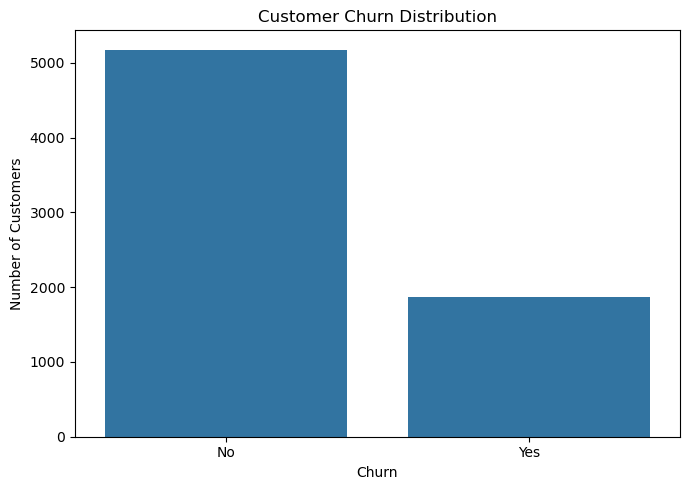

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [17]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")

for column in numerical_columns:
    print("-", column)

Numerical columns:
- SeniorCitizen
- tenure
- MonthlyCharges


In [18]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")

for column in categorical_columns:
    print("-", column)

Categorical columns:
- customerID
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- TotalCharges
- Churn


In [19]:
for column in categorical_columns:
    
    print("\n" + "-" * 10)
    print(column)
    print("-" * 10)
    
    print(df[column].unique())


----------
customerID
----------
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

----------
gender
----------
['Female' 'Male']

----------
Partner
----------
['Yes' 'No']

----------
Dependents
----------
['No' 'Yes']

----------
PhoneService
----------
['No' 'Yes']

----------
MultipleLines
----------
['No phone service' 'No' 'Yes']

----------
InternetService
----------
['DSL' 'Fiber optic' 'No']

----------
OnlineSecurity
----------
['No' 'Yes' 'No internet service']

----------
OnlineBackup
----------
['Yes' 'No' 'No internet service']

----------
DeviceProtection
----------
['No' 'Yes' 'No internet service']

----------
TechSupport
----------
['No' 'Yes' 'No internet service']

----------
StreamingTV
----------
['No' 'Yes' 'No internet service']

----------
StreamingMovies
----------
['No' 'Yes' 'No internet service']

----------
Contract
----------
['Month-to-month' 'One year' 'Two year']

----------
PaperlessBilling
----------
['Yes' 'No']

In [20]:
# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges datatype:")
print(df["TotalCharges"].dtype)

print("\nMissing TotalCharges after conversion:")
print(df["TotalCharges"].isna().sum())

TotalCharges datatype:
float64

Missing TotalCharges after conversion:
11


In [21]:
missing_totalcharges = df[
    df["TotalCharges"].isna()
]

missing_totalcharges[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [22]:
print(
    "Customers with tenure = 0:",
    (df["tenure"] == 0).sum()
)

print(
    "Customers with missing TotalCharges:",
    df["TotalCharges"].isna().sum()
)

print(
    "Customers having both:",
    (
        (df["tenure"] == 0) &
        (df["TotalCharges"].isna())
    ).sum()
)

Customers with tenure = 0: 11
Customers with missing TotalCharges: 11
Customers having both: 11


In [23]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(
    "Remaining missing TotalCharges:",
    df["TotalCharges"].isna().sum()
)

Remaining missing TotalCharges: 0


In [24]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate customer IDs:",
    df["customerID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate customer IDs: 0


In [25]:
churn_count = df["Churn"].value_counts()

churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print("Churn Count:")
print(churn_count)

print("\nChurn Rate (%):")
print(churn_rate.round(2))

Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [26]:
def calculate_churn_rate(dataframe, column):
    
    result = (
        dataframe.groupby(column)["Churn"]
        .apply(
            lambda x:
            (x == "Yes").mean() * 100
        )
        .sort_values(
            ascending=False
        )
        .round(2)
    )
    
    return result

In [27]:
contract_churn = calculate_churn_rate(
    df,
    "Contract"
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

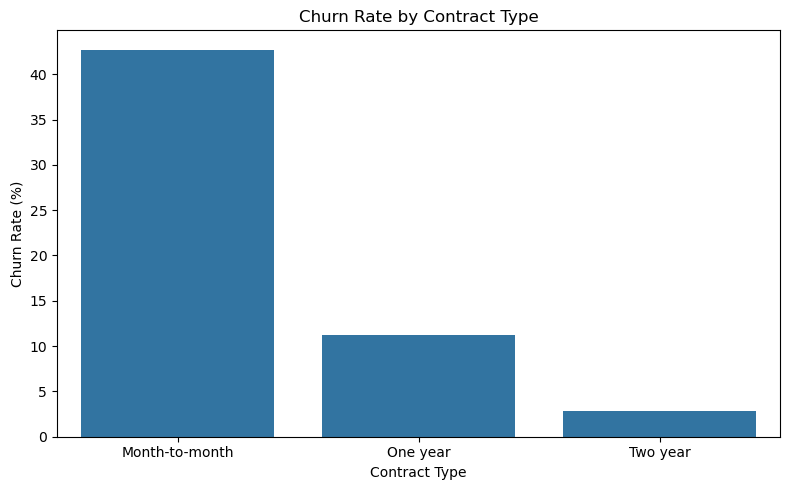

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [29]:
internet_churn = calculate_churn_rate(
    df,
    "InternetService"
)

internet_churn

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

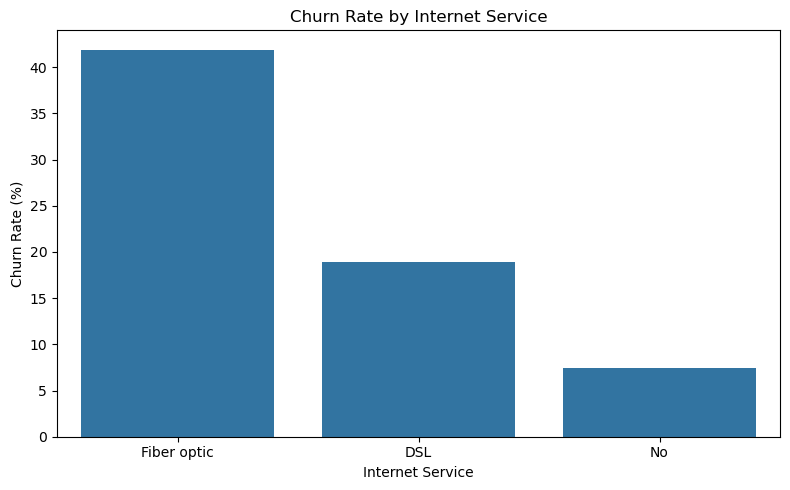

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [31]:
payment_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

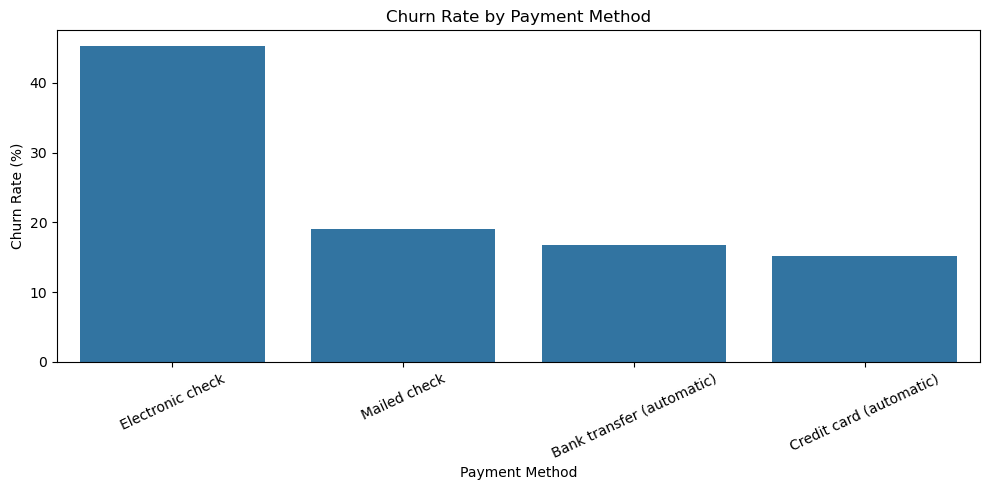

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [33]:
techsupport_churn = calculate_churn_rate(
    df,
    "TechSupport"
)

techsupport_churn

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

In [34]:
security_churn = calculate_churn_rate(
    df,
    "OnlineSecurity"
)

security_churn

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

In [35]:
df.groupby("Churn")["tenure"].agg(
    [
        "count",
        "mean",
        "median",
        "min",
        "max"
    ]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


In [36]:
df.groupby("Churn")["MonthlyCharges"].agg(
    [
        "count",
        "mean",
        "median",
        "min",
        "max"
    ]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


In [37]:
df.groupby("Churn")["TotalCharges"].agg(
    [
        "count",
        "mean",
        "median",
        "min",
        "max"
    ]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,2549.911442,1679.525,0.00,8672.45
Yes,1869,1531.796094,703.550,18.85,8684.80


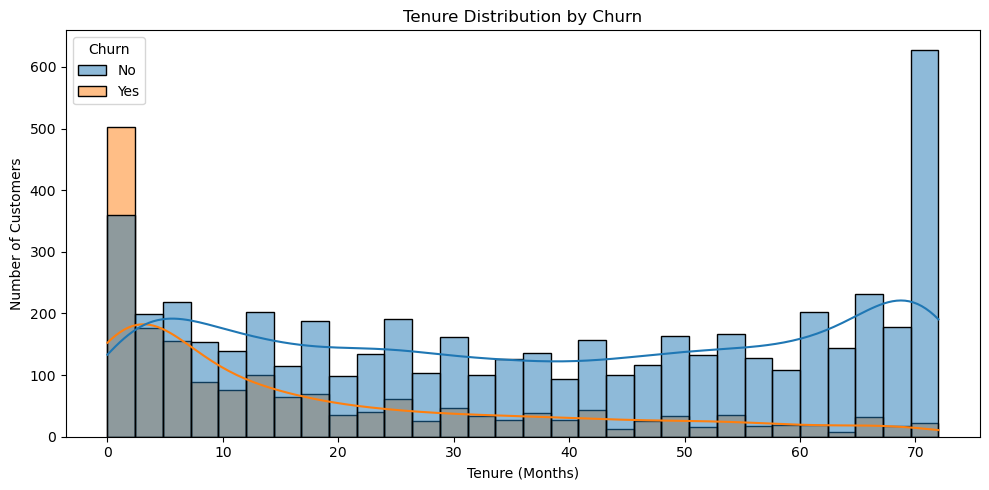

In [38]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

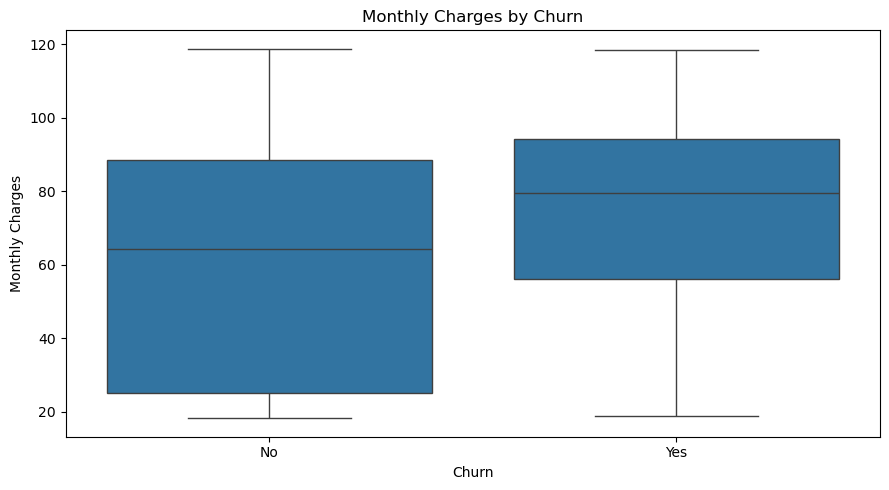

In [39]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

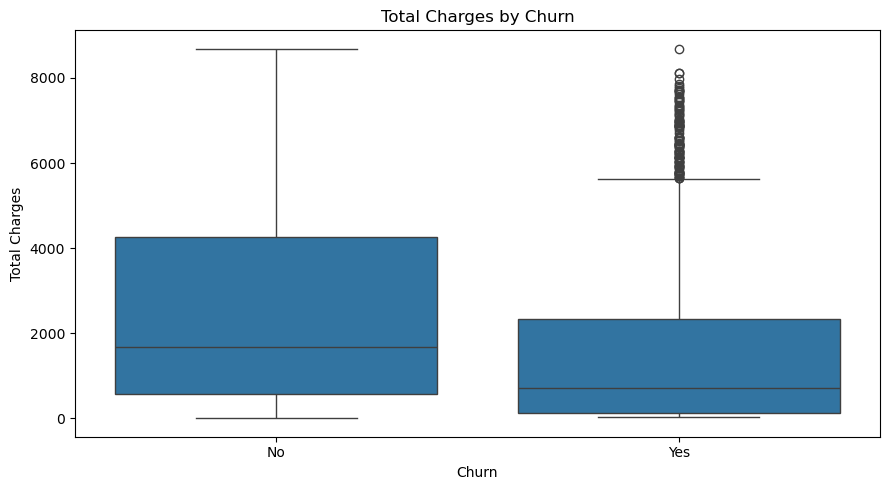

In [40]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

In [41]:
senior_churn = calculate_churn_rate(
    df,
    "SeniorCitizen"
)

senior_churn

SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64

In [42]:
partner_churn = calculate_churn_rate(
    df,
    "Partner"
)

partner_churn

Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

In [43]:
dependents_churn = calculate_churn_rate(
    df,
    "Dependents"
)

dependents_churn

Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

In [44]:
multiple_lines_churn = calculate_churn_rate(
    df,
    "MultipleLines"
)

multiple_lines_churn

MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn, dtype: float64

In [45]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for feature in categorical_features:
    
    print("\n" + "=" * 60)
    print(feature)
    print("=" * 60)
    
    print(
        calculate_churn_rate(
            df,
            feature
        )
    )


gender
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64

Partner
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    26.71
No     24.93
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.13
Yes   

In [46]:
numeric_df = df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

correlation_matrix = numeric_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


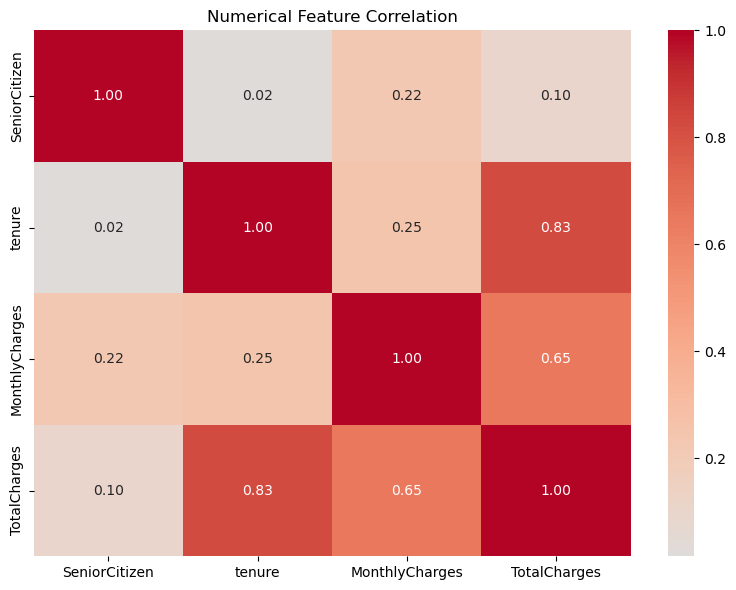

In [47]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.tight_layout()
plt.show()

In [48]:
df["ServiceCount"] = (
    (df["PhoneService"] == "Yes").astype(int)
    +
    (df["MultipleLines"] == "Yes").astype(int)
    +
    (df["OnlineSecurity"] == "Yes").astype(int)
    +
    (df["OnlineBackup"] == "Yes").astype(int)
    +
    (df["DeviceProtection"] == "Yes").astype(int)
    +
    (df["TechSupport"] == "Yes").astype(int)
    +
    (df["StreamingTV"] == "Yes").astype(int)
    +
    (df["StreamingMovies"] == "Yes").astype(int)
)

df["AverageMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

print(
    df[
        [
            "ServiceCount",
            "AverageMonthlySpend"
        ]
    ].head()
)

   ServiceCount  AverageMonthlySpend
0             1            29.850000
1             3            55.573529
2             3            54.075000
3             3            40.905556
4             1            75.825000


In [49]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[
        -1,
        6,
        12,
        24,
        48,
        np.inf
    ],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

df[
    [
        "tenure",
        "TenureGroup"
    ]
].head(10)

,tenure,TenureGroup
0,1,0-6 Months
1,34,25-48 Months
2,2,0-6 Months
3,45,25-48 Months
4,2,0-6 Months
5,8,7-12 Months
6,22,13-24 Months
7,10,7-12 Months
8,28,25-48 Months
9,62,49+ Months


In [50]:
tenure_group_churn = calculate_churn_rate(
    df,
    "TenureGroup"
)

tenure_group_churn

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16492\1821190203.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataframe.groupby(column)["Churn"]


TenureGroup
0-6 Months      52.94
7-12 Months     35.89
13-24 Months    28.71
25-48 Months    20.39
49+ Months       9.51
Name: Churn, dtype: float64

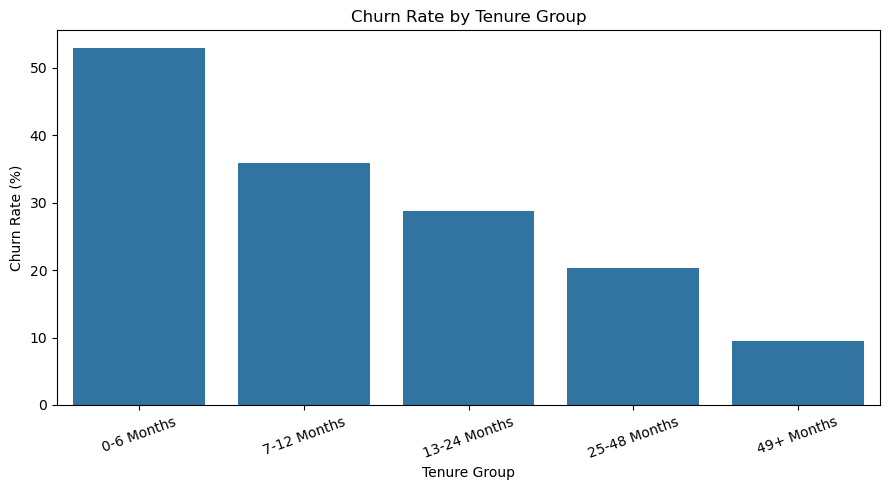

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_group_churn.index,
    y=tenure_group_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [52]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Dataset shape: (7043, 24)

Missing values:
customerID             0
gender                 0
AverageMonthlySpend    0
ServiceCount           0
Churn                  0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Contract               0
StreamingMovies        0
StreamingTV            0
TechSupport            0
DeviceProtection       0
OnlineBackup           0
OnlineSecurity         0
InternetService        0
MultipleLines          0
PhoneService           0
tenure                 0
dtype: int64


In [53]:
model_df = df.copy()

model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(
    model_df["Churn"].value_counts()
)

Churn
0    5174
1    1869
Name: count, dtype: int64


In [54]:
model_df = model_df.drop(
    columns=["customerID"]
)

print(
    "New dataset shape:",
    model_df.shape
)

New dataset shape: (7043, 23)


In [55]:
X = model_df.drop(
    columns=["Churn"]
)

y = model_df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 22)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [56]:
possible_leakage_columns = [
    "Churn Reason",
    "Churn Category",
    "Churn Score",
    "Churn Value",
    "Cancellation Date",
    "Customer Status"
]

found_leakage_columns = [
    column
    for column in possible_leakage_columns
    if column in X.columns
]

print(
    "Potential leakage columns found:"
)

print(found_leakage_columns)

Potential leakage columns found:
[]


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (5634, 22)
Testing data : (1409, 22)


In [58]:
print("Training target distribution:")
print(
    y_train.value_counts(normalize=True)
    .round(4)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .round(4)
)

Training target distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [59]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AverageMonthlySpend']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


In [61]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [62]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [63]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [64]:
y_pred_logistic = logistic_model.predict(
    X_test
)

y_prob_logistic = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [65]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }
    
    return results

In [66]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7977288857345636,
 'Precision': 0.6539792387543253,
 'Recall': 0.5053475935828877,
 'F1': 0.5701357466063348,
 'ROC_AUC': 0.8454106280193238,
 'PR_AUC': 0.6519642401050431}

In [67]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



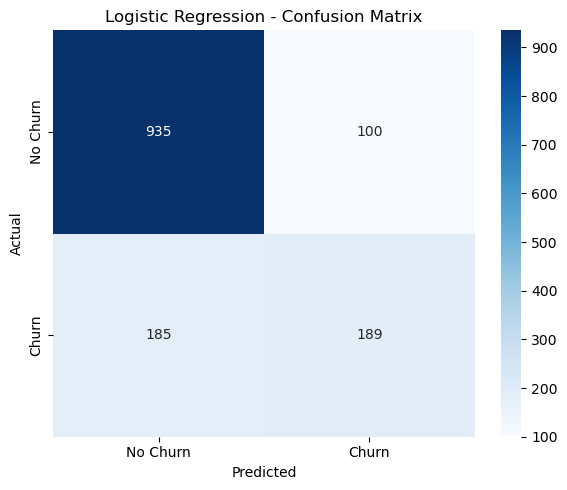

In [68]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Random Forest

In [69]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [70]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [71]:
y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [72]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7686302342086586,
 'Precision': 0.548,
 'Recall': 0.732620320855615,
 'F1': 0.6270022883295194,
 'ROC_AUC': 0.8420083184789067,
 'PR_AUC': 0.651626007608129}

In [73]:
results_df = pd.DataFrame(
    [
        logistic_results,
        rf_results
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.797729,0.653979,0.505348,0.570136,0.845411,0.651964
1,Random Forest,0.768630,0.548000,0.732620,0.627002,0.842008,0.651626


In [74]:
results_df.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.797729,0.653979,0.505348,0.570136,0.845411,0.651964
1,Random Forest,0.768630,0.548000,0.732620,0.627002,0.842008,0.651626


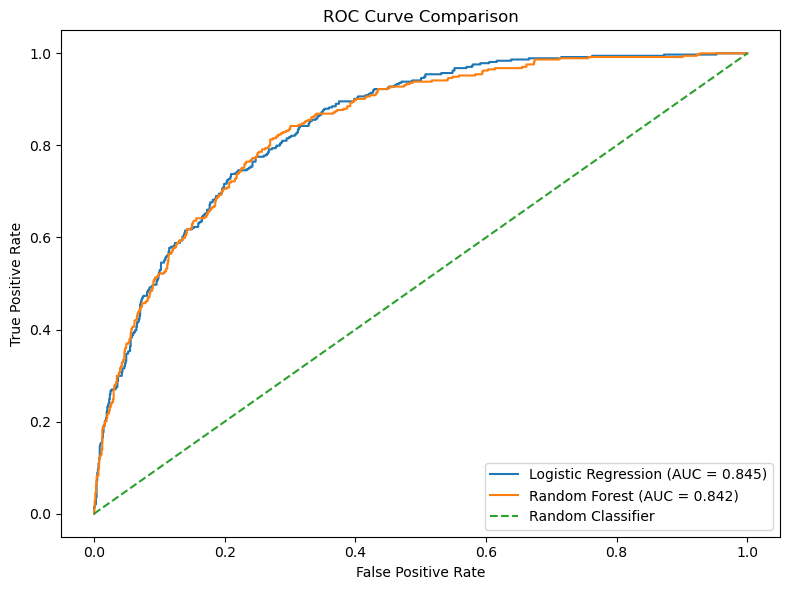

In [75]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()
plt.show()

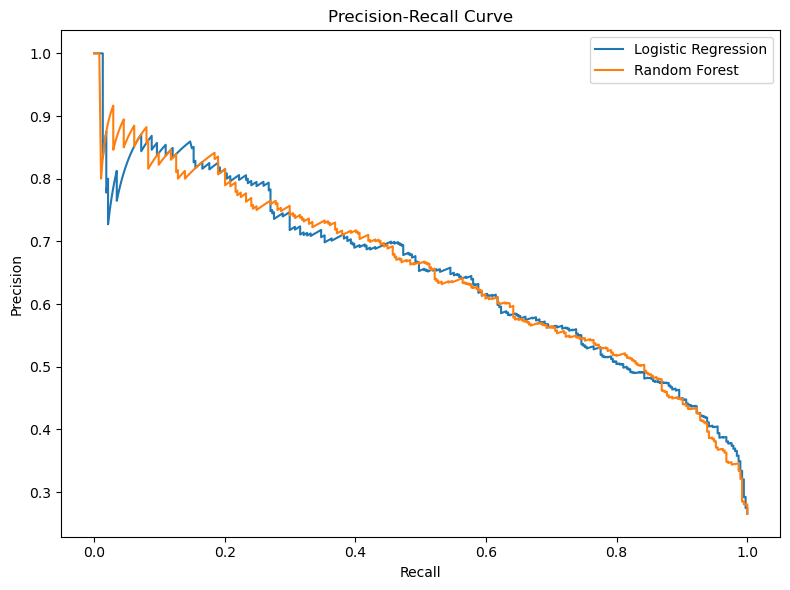

In [76]:
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.tight_layout()
plt.show()

In [77]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("No Churn:", negative_count)
print("Churn:", positive_count)
print("Scale Pos Weight:", round(scale_pos_weight, 3))

No Churn: 4139
Churn: 1495
Scale Pos Weight: 2.769


In [78]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                max_depth=4,
                learning_rate=0.03,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=3,
                reg_alpha=0.1,
                reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created!")

XGBoost pipeline created!


In [79]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [80]:
y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [81]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7579843860894251,
 'Precision': 0.5296229802513465,
 'Recall': 0.7887700534759359,
 'F1': 0.6337271750805585,
 'ROC_AUC': 0.8424126172208013,
 'PR_AUC': 0.655821227828299}

In [82]:
results_df = pd.DataFrame(
    [
        logistic_results,
        rf_results,
        xgb_results
    ]
)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.757984,0.529623,0.788770,0.633727,0.842413,0.655821
1,Logistic Regression,0.797729,0.653979,0.505348,0.570136,0.845411,0.651964
2,Random Forest,0.768630,0.548000,0.732620,0.627002,0.842008,0.651626


In [83]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



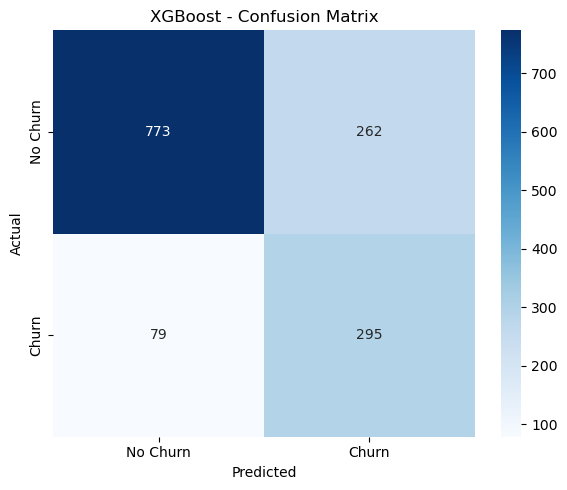

In [84]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [85]:
results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "PR_AUC": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.758,0.530,0.789,0.634,0.842,0.656
1,Logistic Regression,0.798,0.654,0.505,0.570,0.845,0.652
2,Random Forest,0.769,0.548,0.733,0.627,0.842,0.652


## Cross Validation

In [86]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross Validation ready!")

5-Fold Stratified Cross Validation ready!


In [87]:
logistic_cv = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "roc_auc",
        "average_precision",
        "f1",
        "precision",
        "recall"
    ],
    n_jobs=-1
)

print(
    "Logistic Regression Mean ROC-AUC:",
    round(
        logistic_cv["test_roc_auc"].mean(),
        4
    )
)

print(
    "Logistic Regression Mean PR-AUC:",
    round(
        logistic_cv["test_average_precision"].mean(),
        4
    )
)

Logistic Regression Mean ROC-AUC: 0.8472
Logistic Regression Mean PR-AUC: 0.6622


In [88]:
rf_cv = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "roc_auc",
        "average_precision",
        "f1",
        "precision",
        "recall"
    ],
    n_jobs=-1
)

print(
    "Random Forest Mean ROC-AUC:",
    round(
        rf_cv["test_roc_auc"].mean(),
        4
    )
)

print(
    "Random Forest Mean PR-AUC:",
    round(
        rf_cv["test_average_precision"].mean(),
        4
    )
)

Random Forest Mean ROC-AUC: 0.8445
Random Forest Mean PR-AUC: 0.6609


In [89]:
xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "roc_auc",
        "average_precision",
        "f1",
        "precision",
        "recall"
    ],
    n_jobs=-1
)

print(
    "XGBoost Mean ROC-AUC:",
    round(
        xgb_cv["test_roc_auc"].mean(),
        4
    )
)

print(
    "XGBoost Mean PR-AUC:",
    round(
        xgb_cv["test_average_precision"].mean(),
        4
    )
)

XGBoost Mean ROC-AUC: 0.8442
XGBoost Mean PR-AUC: 0.6609


In [90]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Mean_ROC_AUC": [
        logistic_cv["test_roc_auc"].mean(),
        rf_cv["test_roc_auc"].mean(),
        xgb_cv["test_roc_auc"].mean()
    ],
    
    "Mean_PR_AUC": [
        logistic_cv["test_average_precision"].mean(),
        rf_cv["test_average_precision"].mean(),
        xgb_cv["test_average_precision"].mean()
    ],
    
    "Mean_F1": [
        logistic_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean(),
        xgb_cv["test_f1"].mean()
    ],
    
    "Mean_Precision": [
        logistic_cv["test_precision"].mean(),
        rf_cv["test_precision"].mean(),
        xgb_cv["test_precision"].mean()
    ],
    
    "Mean_Recall": [
        logistic_cv["test_recall"].mean(),
        rf_cv["test_recall"].mean(),
        xgb_cv["test_recall"].mean()
    ]
})

cv_results.sort_values(
    "Mean_PR_AUC",
    ascending=False
).reset_index(drop=True)

,Model,Mean_ROC_AUC,Mean_PR_AUC,Mean_F1,Mean_Precision,Mean_Recall
0,Logistic Regression,0.847210,0.662167,0.594879,0.673209,0.533779
1,Random Forest,0.844479,0.660944,0.631379,0.566217,0.713712
2,XGBoost,0.844213,0.660925,0.632899,0.532882,0.779264


## THRESHOLD OPTIMIZATION

In [91]:
def evaluate_thresholds(
    y_true,
    y_prob,
    thresholds=np.arange(0.10, 0.91, 0.01)
):
    
    threshold_results = []
    
    for threshold in thresholds:
        
        y_pred = (
            y_prob >= threshold
        ).astype(int)
        
        threshold_results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "Predicted_Churn_Rate": y_pred.mean()
        })
    
    return pd.DataFrame(
        threshold_results
    )

In [92]:
logistic_thresholds = evaluate_thresholds(
    y_test,
    y_prob_logistic
)

logistic_thresholds.head()

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
0,0.10,0.405530,0.941176,0.566828,0.616040
1,0.11,0.413915,0.938503,0.574468,0.601845
2,0.12,0.421308,0.930481,0.580000,0.586231
3,0.13,0.426980,0.922460,0.583756,0.573456
4,0.14,0.437103,0.919786,0.592593,0.558552


In [93]:
rf_thresholds = evaluate_thresholds(
    y_test,
    y_prob_rf
)

rf_thresholds.head()

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
0,0.10,0.344601,0.981283,0.510076,0.755855
1,0.11,0.347036,0.970588,0.511268,0.742370
2,0.12,0.357002,0.967914,0.521614,0.719659
3,0.13,0.365385,0.965241,0.530103,0.701207
4,0.14,0.369183,0.954545,0.532438,0.686302


In [94]:
xgb_thresholds = evaluate_thresholds(
    y_test,
    y_prob_xgb
)

xgb_thresholds.head()

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
0,0.10,0.358135,0.965241,0.522431,0.715401
1,0.11,0.364372,0.962567,0.528634,0.701207
2,0.12,0.367556,0.957219,0.531157,0.691270
3,0.13,0.372651,0.954545,0.536036,0.679915
4,0.14,0.377919,0.951872,0.541033,0.668559


## PART 7 — OUT-OF-FOLD VALIDATION

In [95]:
from sklearn.model_selection import cross_val_predict

logistic_oof_prob = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

rf_oof_prob = cross_val_predict(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_oof_prob = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities generated successfully!")

OOF probabilities generated successfully!


In [96]:
oof_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(
            y_train,
            logistic_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            logistic_oof_prob
        )
    },
    
    {
        "Model": "Random Forest",
        "ROC_AUC": roc_auc_score(
            y_train,
            rf_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            rf_oof_prob
        )
    },
    
    {
        "Model": "XGBoost",
        "ROC_AUC": roc_auc_score(
            y_train,
            xgb_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            xgb_oof_prob
        )
    }
])

oof_results

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.847005,0.659931
1,Random Forest,0.843834,0.657799
2,XGBoost,0.843557,0.657134


In [97]:
logistic_oof_thresholds = evaluate_thresholds(
    y_train,
    logistic_oof_prob
)

rf_oof_thresholds = evaluate_thresholds(
    y_train,
    rf_oof_prob
)

xgb_oof_thresholds = evaluate_thresholds(
    y_train,
    xgb_oof_prob
)

print("OOF threshold analysis completed!")

OOF threshold analysis completed!


In [98]:
best_logistic_threshold = (
    logistic_oof_thresholds
    .loc[
        logistic_oof_thresholds["F1"].idxmax(),
        "Threshold"
    ]
)

best_rf_threshold = (
    rf_oof_thresholds
    .loc[
        rf_oof_thresholds["F1"].idxmax(),
        "Threshold"
    ]
)

best_xgb_threshold = (
    xgb_oof_thresholds
    .loc[
        xgb_oof_thresholds["F1"].idxmax(),
        "Threshold"
    ]
)

print(
    "Logistic Regression threshold:",
    round(best_logistic_threshold, 2)
)

print(
    "Random Forest threshold:",
    round(best_rf_threshold, 2)
)

print(
    "XGBoost threshold:",
    round(best_xgb_threshold, 2)
)

Logistic Regression threshold: 0.33
Random Forest threshold: 0.51
XGBoost threshold: 0.54


In [99]:
threshold_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": best_logistic_threshold,
        "Precision": logistic_oof_thresholds.loc[
            logistic_oof_thresholds["Threshold"]
            == best_logistic_threshold,
            "Precision"
        ].iloc[0],
        "Recall": logistic_oof_thresholds.loc[
            logistic_oof_thresholds["Threshold"]
            == best_logistic_threshold,
            "Recall"
        ].iloc[0],
        "F1": logistic_oof_thresholds.loc[
            logistic_oof_thresholds["Threshold"]
            == best_logistic_threshold,
            "F1"
        ].iloc[0]
    },
    
    {
        "Model": "Random Forest",
        "Threshold": best_rf_threshold,
        "Precision": rf_oof_thresholds.loc[
            rf_oof_thresholds["Threshold"]
            == best_rf_threshold,
            "Precision"
        ].iloc[0],
        "Recall": rf_oof_thresholds.loc[
            rf_oof_thresholds["Threshold"]
            == best_rf_threshold,
            "Recall"
        ].iloc[0],
        "F1": rf_oof_thresholds.loc[
            rf_oof_thresholds["Threshold"]
            == best_rf_threshold,
            "F1"
        ].iloc[0]
    },
    
    {
        "Model": "XGBoost",
        "Threshold": best_xgb_threshold,
        "Precision": xgb_oof_thresholds.loc[
            xgb_oof_thresholds["Threshold"]
            == best_xgb_threshold,
            "Precision"
        ].iloc[0],
        "Recall": xgb_oof_thresholds.loc[
            xgb_oof_thresholds["Threshold"]
            == best_xgb_threshold,
            "Recall"
        ].iloc[0],
        "F1": xgb_oof_thresholds.loc[
            xgb_oof_thresholds["Threshold"]
            == best_xgb_threshold,
            "F1"
        ].iloc[0]
    }
])

threshold_comparison

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.33,0.565940,0.729097,0.637241
1,Random Forest,0.51,0.571506,0.708361,0.632616
2,XGBoost,0.54,0.558779,0.747157,0.639382


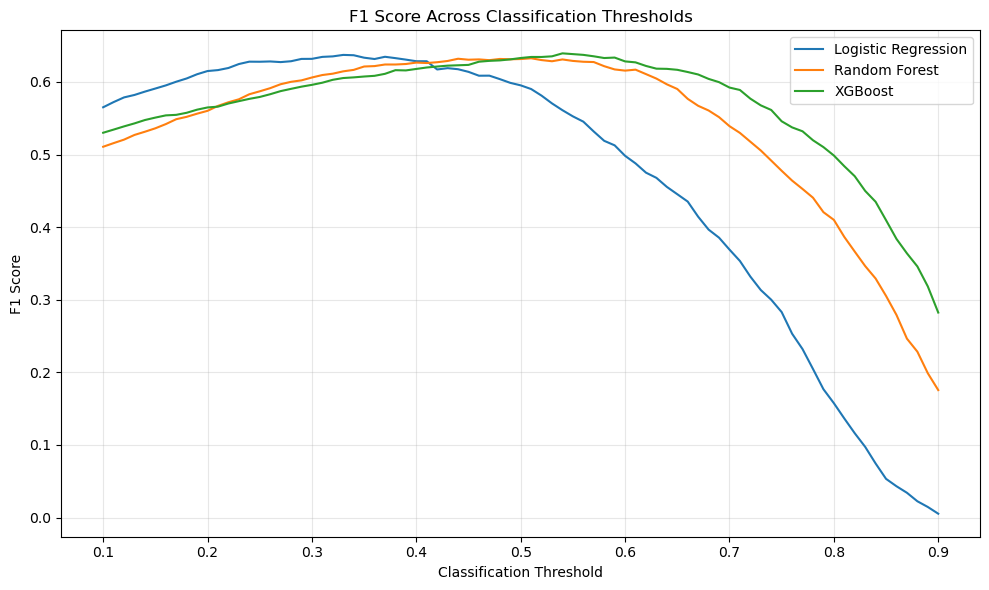

In [100]:
plt.figure(figsize=(10, 6))

plt.plot(
    logistic_oof_thresholds["Threshold"],
    logistic_oof_thresholds["F1"],
    label="Logistic Regression"
)

plt.plot(
    rf_oof_thresholds["Threshold"],
    rf_oof_thresholds["F1"],
    label="Random Forest"
)

plt.plot(
    xgb_oof_thresholds["Threshold"],
    xgb_oof_thresholds["F1"],
    label="XGBoost"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score Across Classification Thresholds")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

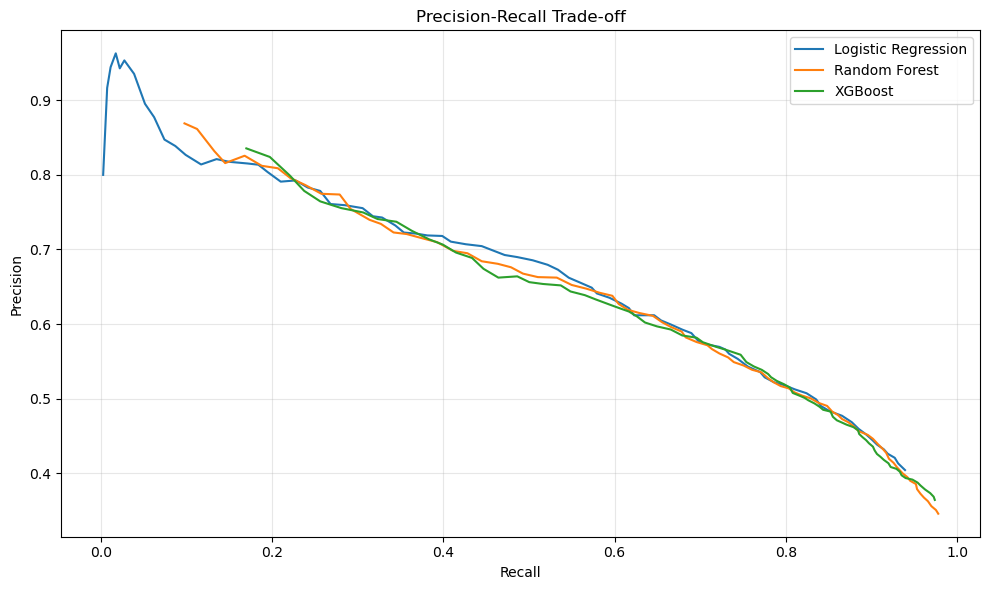

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(
    logistic_oof_thresholds["Recall"],
    logistic_oof_thresholds["Precision"],
    label="Logistic Regression"
)

plt.plot(
    rf_oof_thresholds["Recall"],
    rf_oof_thresholds["Precision"],
    label="Random Forest"
)

plt.plot(
    xgb_oof_thresholds["Recall"],
    xgb_oof_thresholds["Precision"],
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [102]:
def create_risk_segment(probabilities):
    
    return pd.cut(
        probabilities,
        bins=[
            -np.inf,
            0.30,
            0.60,
            np.inf
        ],
        labels=[
            "Low Risk",
            "Medium Risk",
            "High Risk"
        ]
    )

In [103]:
risk_analysis = X_test.copy()

risk_analysis["Actual_Churn"] = y_test.values

risk_analysis["Churn_Probability"] = (
    y_prob_xgb
)

risk_analysis["Risk_Segment"] = (
    create_risk_segment(
        y_prob_xgb
    )
)

risk_analysis[
    [
        "Churn_Probability",
        "Risk_Segment",
        "Actual_Churn"
    ]
].head(10)

,Churn_Probability,Risk_Segment,Actual_Churn
437,0.022916,Low Risk,0
2280,0.933373,High Risk,0
2235,0.201363,Low Risk,0
4460,0.538100,Medium Risk,0
3761,0.008882,Low Risk,0
5748,0.838459,High Risk,0
3568,0.690646,High Risk,0
2976,0.302926,Medium Risk,0
5928,0.024053,Low Risk,0
1639,0.723001,High Risk,1


In [104]:
risk_summary = (
    risk_analysis
    .groupby(
        "Risk_Segment",
        observed=True
    )
    .agg(
        Customers=("Actual_Churn", "count"),
        Actual_Churn_Rate=("Actual_Churn", "mean"),
        Average_Predicted_Probability=(
            "Churn_Probability",
            "mean"
        )
    )
)

risk_summary["Actual_Churn_Rate"] *= 100

risk_summary.round(2)

,Customers,Actual_Churn_Rate,Average_Predicted_Probability
Risk_Segment,,,
Low Risk,673,5.94,0.10
Medium Risk,266,25.94,0.45
High Risk,470,56.38,0.77


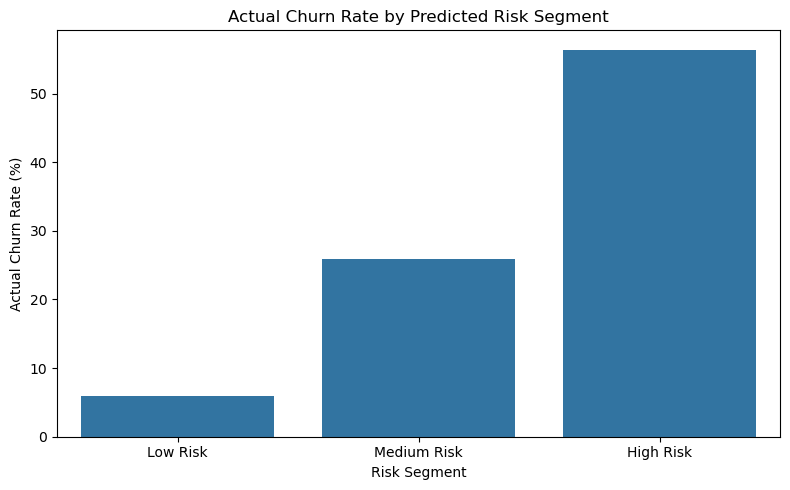

In [105]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_summary.reset_index(),
    x="Risk_Segment",
    y="Actual_Churn_Rate"
)

plt.title("Actual Churn Rate by Predicted Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Actual Churn Rate (%)")

plt.tight_layout()
plt.show()

In [106]:
top_risk_customers = (
    risk_analysis
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(20)
)

top_risk_customers[
    [
        "Churn_Probability",
        "Risk_Segment",
        "Actual_Churn"
    ]
]

,Churn_Probability,Risk_Segment,Actual_Churn
3380,0.972121,High Risk,1
6866,0.970749,High Risk,1
4585,0.968801,High Risk,1
6623,0.966835,High Risk,1
2464,0.963543,High Risk,1
2631,0.962290,High Risk,1
1731,0.957397,High Risk,1
1073,0.955426,High Risk,1
6748,0.955279,High Risk,1
2194,0.954230,High Risk,1


In [107]:
def top_k_capture(
    y_true,
    y_prob,
    k_values=np.arange(5, 51, 5)
):
    
    data = pd.DataFrame({
        "Actual": np.array(y_true),
        "Probability": np.array(y_prob)
    })
    
    data = data.sort_values(
        "Probability",
        ascending=False
    )
    
    total_churners = data["Actual"].sum()
    
    results = []
    
    for k in k_values:
        
        n_customers = max(
            1,
            int(len(data) * k / 100)
        )
        
        selected = data.head(
            n_customers
        )
        
        captured_churners = (
            selected["Actual"].sum()
        )
        
        capture_rate = (
            captured_churners /
            total_churners
            if total_churners > 0
            else 0
        )
        
        results.append({
            "Top_%_Customers": k,
            "Customers_Targeted": n_customers,
            "Churners_Captured": int(
                captured_churners
            ),
            "Capture_Rate_%": capture_rate * 100
        })
    
    return pd.DataFrame(results)

In [108]:
top_k_results = top_k_capture(
    y_test,
    y_prob_xgb
)

top_k_results

,Top_%_Customers,Customers_Targeted,Churners_Captured,Capture_Rate_%
0,5,70,56,14.973262
1,10,140,106,28.342246
2,15,211,151,40.374332
3,20,281,190,50.802139
4,25,352,216,57.754011
5,30,422,247,66.042781
6,35,493,271,72.459893
7,40,563,297,79.411765
8,45,634,309,82.620321
9,50,704,330,88.235294


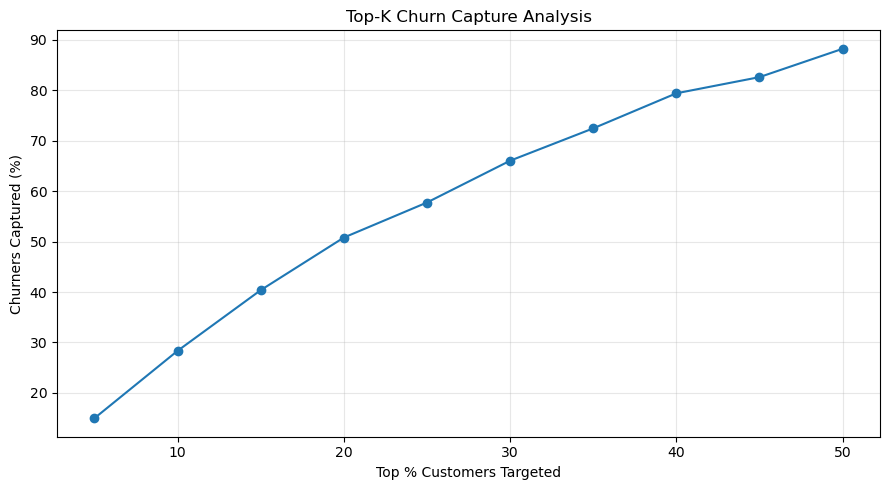

In [109]:
plt.figure(figsize=(9, 5))

plt.plot(
    top_k_results["Top_%_Customers"],
    top_k_results["Capture_Rate_%"],
    marker="o"
)

plt.xlabel("Top % Customers Targeted")
plt.ylabel("Churners Captured (%)")
plt.title("Top-K Churn Capture Analysis")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 9 — MODEL PROBABILITY CALIBRATION

In [110]:
from sklearn.calibration import calibration_curve

print("Calibration tools imported!")

Calibration tools imported!


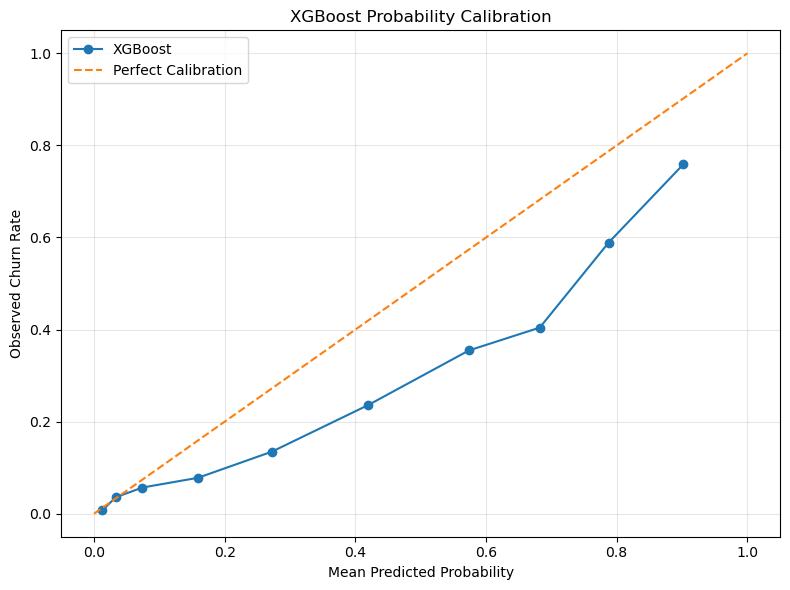

In [111]:
prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test,
    y_prob_xgb,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("XGBoost Probability Calibration")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 10 — CATBOOST

In [112]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# Convert categorical columns to string
for column in categorical_features:
    X_train_cb[column] = (
        X_train_cb[column]
        .astype(str)
    )
    
    X_test_cb[column] = (
        X_test_cb[column]
        .astype(str)
    )

# CatBoost categorical feature indices
cat_feature_indices = [
    X_train_cb.columns.get_loc(column)
    for column in categorical_features
]

print("CatBoost training shape:", X_train_cb.shape)
print("Categorical feature count:", len(cat_feature_indices))

CatBoost training shape: (5634, 22)
Categorical feature count: 16


In [113]:
catboost_model = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    class_weights=[
        1.0,
        scale_pos_weight
    ],
    l2_leaf_reg=5
)

print("CatBoost model created!")

CatBoost model created!


In [114]:
catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices
)

print("CatBoost training completed!")

CatBoost training completed!


In [115]:
y_pred_cb = catboost_model.predict(
    X_test_cb
).astype(int).ravel()

y_prob_cb = catboost_model.predict_proba(
    X_test_cb
)[:, 1]

print("CatBoost predictions generated!")

CatBoost predictions generated!


In [116]:
catboost_results = evaluate_model(
    "CatBoost",
    y_test,
    y_pred_cb,
    y_prob_cb
)

catboost_results

{'Model': 'CatBoost',
 'Accuracy': 0.7643718949609652,
 'Precision': 0.5388888888888889,
 'Recall': 0.7780748663101604,
 'F1': 0.6367614879649891,
 'ROC_AUC': 0.8453783357875431,
 'PR_AUC': 0.6621219788228028}

In [117]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results,
    catboost_results
])

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.764372,0.538889,0.778075,0.636761,0.845378,0.662122
1,XGBoost,0.757984,0.529623,0.788770,0.633727,0.842413,0.655821
2,Logistic Regression,0.797729,0.653979,0.505348,0.570136,0.845411,0.651964
3,Random Forest,0.768630,0.548000,0.732620,0.627002,0.842008,0.651626


In [118]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "PR_AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.7644,0.5389,0.7781,0.6368,0.8454,0.6621
1,XGBoost,0.7580,0.5296,0.7888,0.6337,0.8424,0.6558
2,Logistic Regression,0.7977,0.6540,0.5053,0.5701,0.8454,0.6520
3,Random Forest,0.7686,0.5480,0.7326,0.6270,0.8420,0.6516


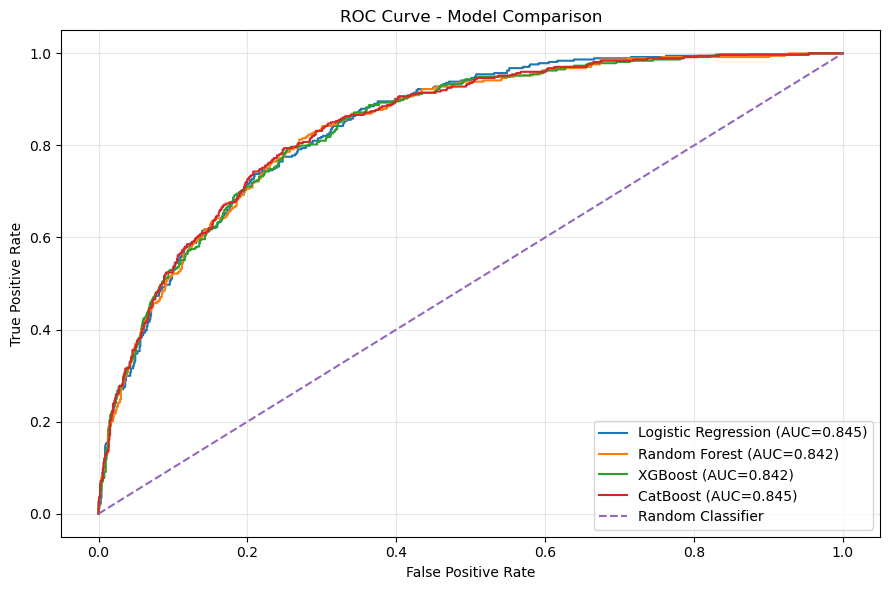

In [119]:
roc_predictions = {
    "Logistic Regression": y_prob_logistic,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "CatBoost": y_prob_cb
}

plt.figure(figsize=(9, 6))

for model_name, probabilities in roc_predictions.items():
    
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )
    
    auc_score = roc_auc_score(
        y_test,
        probabilities
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

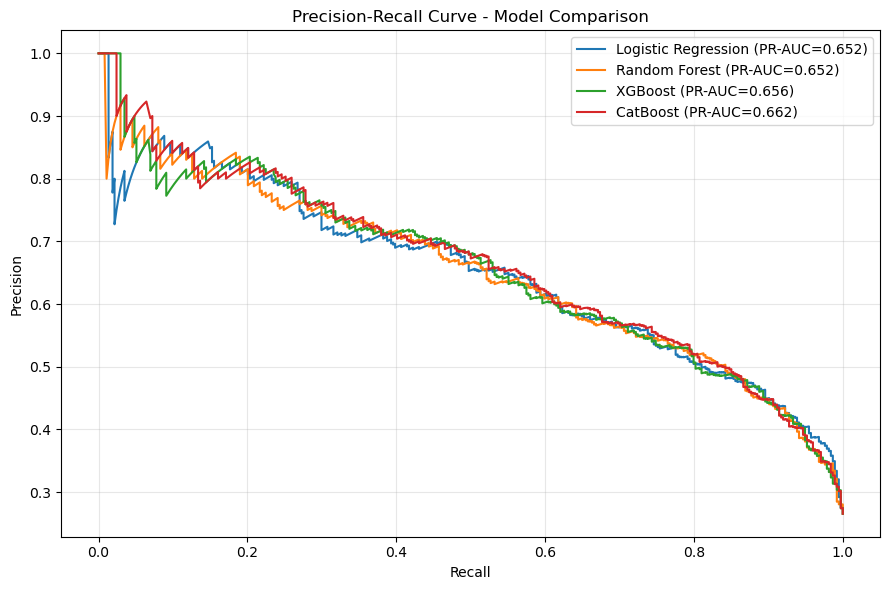

In [120]:
plt.figure(figsize=(9, 6))

for model_name, probabilities in roc_predictions.items():
    
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )
    
    pr_auc = average_precision_score(
        y_test,
        probabilities
    )
    
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

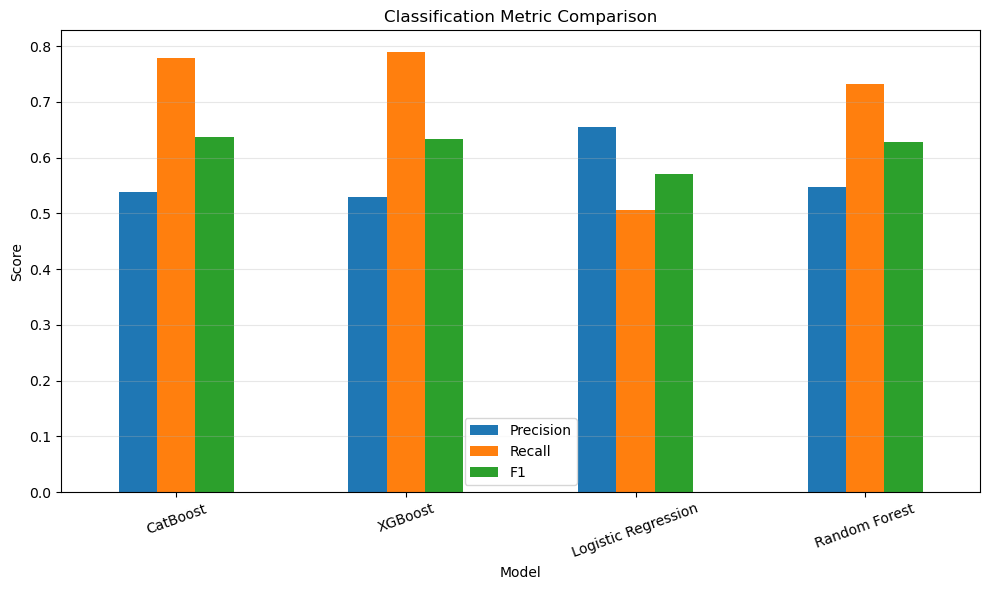

In [121]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1"
]

plot_data = results_df[
    ["Model"] + metrics_to_plot
].copy()

plot_data = plot_data.set_index(
    "Model"
)

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Metric Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
xgb_preprocessor = (
    xgb_model
    .named_steps["preprocessor"]
)

xgb_classifier = (
    xgb_model
    .named_steps["classifier"]
)

feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

print(
    "Total transformed features:",
    len(feature_names)
)

Total transformed features: 36


In [123]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_classifier.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

xgb_importance.head(20)

,Feature,Importance
0,cat__Contract_Two year,0.251469
1,cat__InternetService_Fiber optic,0.125640
2,cat__Contract_One year,0.117867
3,cat__OnlineSecurity_No internet service,0.061456
4,cat__InternetService_No,0.060947
5,cat__TenureGroup_49+ Months,0.054197
6,cat__PaymentMethod_Electronic check,0.038001
7,cat__StreamingMovies_Yes,0.032640
8,num__tenure,0.020685
9,cat__PaperlessBilling_Yes,0.015818


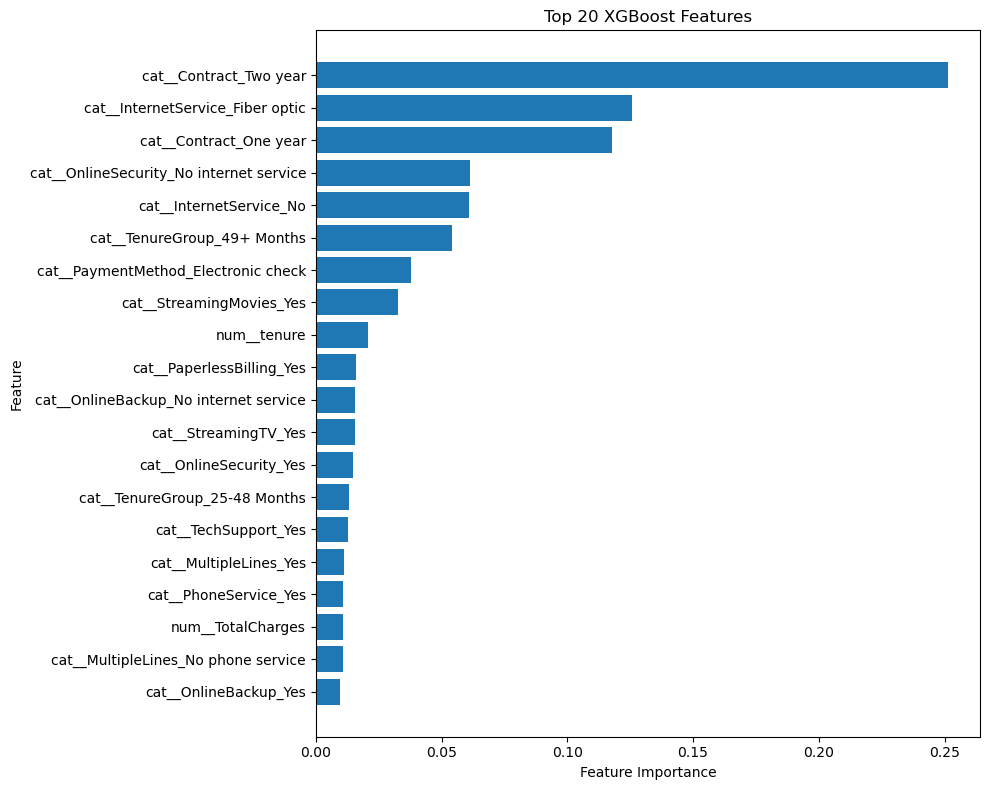

In [124]:
top_features = (
    xgb_importance
    .head(20)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

In [125]:
catboost_importance = pd.DataFrame({
    "Feature": X_train_cb.columns,
    "Importance": catboost_model.get_feature_importance()
})

catboost_importance = (
    catboost_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

catboost_importance.head(20)

,Feature,Importance
0,Contract,18.867007
1,tenure,11.314880
2,TotalCharges,8.208953
3,InternetService,7.675244
4,PaymentMethod,6.742892
5,AverageMonthlySpend,5.273979
6,TenureGroup,5.142803
7,OnlineSecurity,5.047906
8,MultipleLines,4.745096
9,MonthlyCharges,4.603576


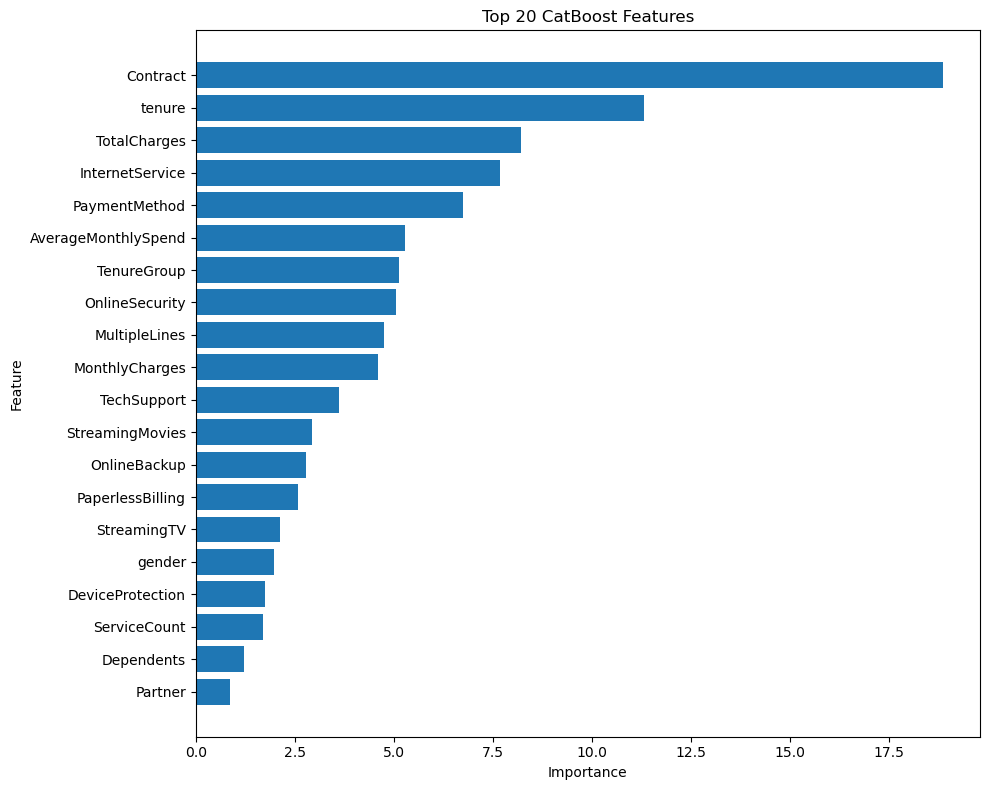

In [126]:
top_cb_features = (
    catboost_importance
    .head(20)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_cb_features["Feature"],
    top_cb_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Features")

plt.tight_layout()
plt.show()

In [127]:
import shap

print(
    "SHAP version:",
    shap.__version__
)

SHAP version: 0.52.0


In [128]:
X_test_transformed = (
    xgb_preprocessor
    .transform(X_test)
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Transformed test shape: (1409, 36)


In [129]:
if hasattr(
    X_test_transformed,
    "toarray"
):
    
    X_test_shap = (
        X_test_transformed
        .toarray()
    )

else:
    
    X_test_shap = X_test_transformed

print(
    "SHAP matrix shape:",
    X_test_shap.shape
)

SHAP matrix shape: (1409, 36)


In [130]:
explainer = shap.TreeExplainer(
    xgb_classifier
)

shap_values = explainer(
    X_test_shap
)

print("SHAP values generated successfully!")

SHAP values generated successfully!


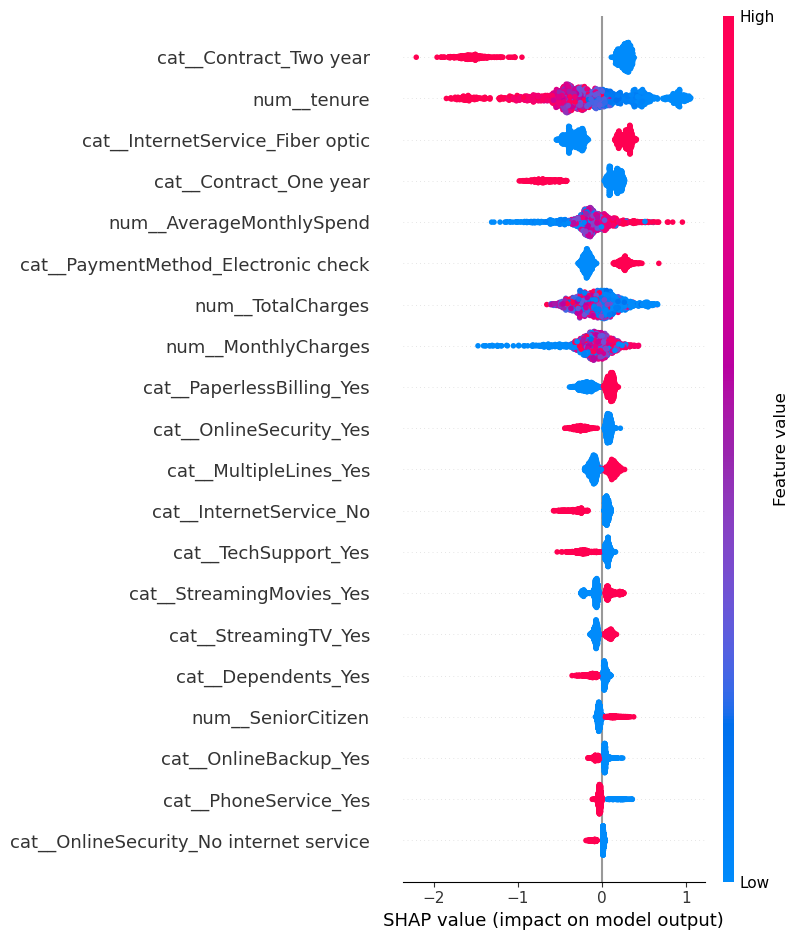

In [131]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    show=True
)

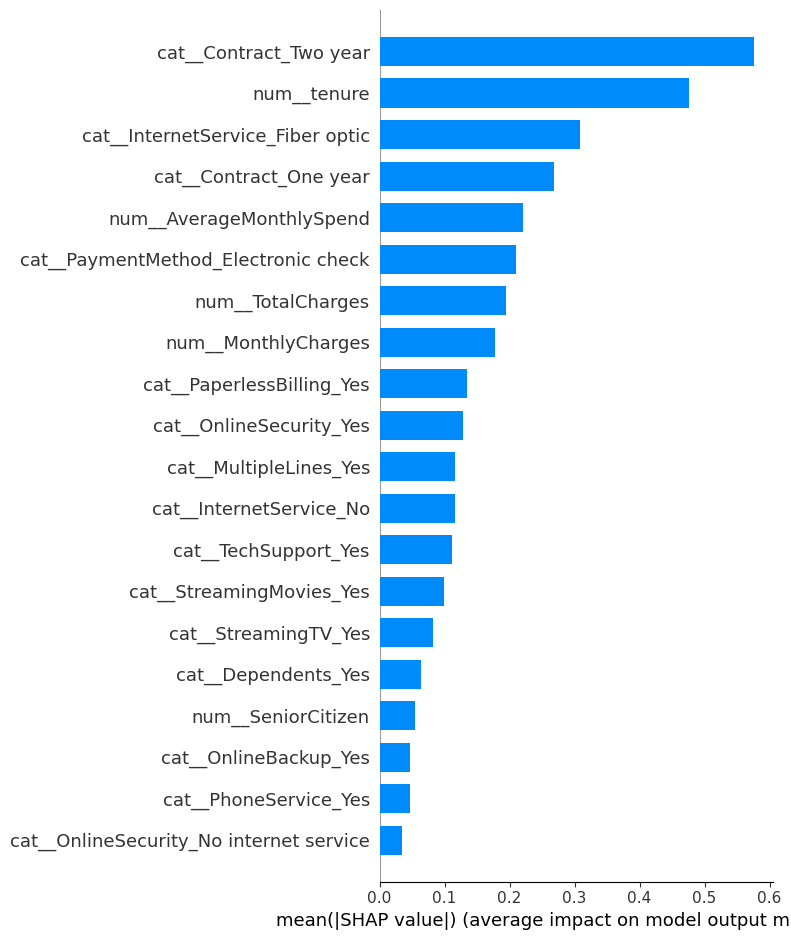

In [132]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

In [133]:
customer_index = 0

print(
    "Customer index:",
    customer_index
)

print(
    "Actual churn:",
    y_test.iloc[customer_index]
)

print(
    "Predicted churn probability:",
    round(
        y_prob_xgb[customer_index],
        4
    )
)

Customer index: 0
Actual churn: 0
Predicted churn probability: 0.0229


In [134]:
X_test.iloc[
    [customer_index]
].T

,437
gender,Male
SeniorCitizen,0
Partner,Yes
Dependents,Yes
tenure,72
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,Yes
OnlineBackup,Yes


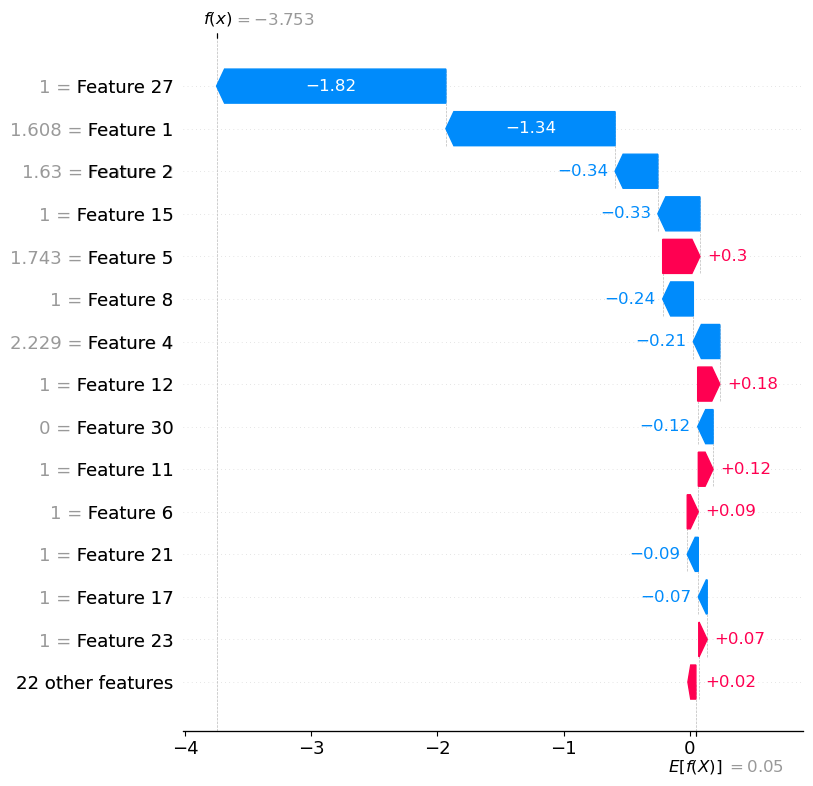

In [135]:
shap.waterfall_plot(
    shap_values[customer_index],
    max_display=15
)

In [136]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values

error_analysis["Predicted"] = (
    y_pred_xgb
)

error_analysis["Probability"] = (
    y_prob_xgb
)

error_analysis["Prediction_Type"] = np.select(
    [
        (
            (error_analysis["Actual"] == 1) &
            (error_analysis["Predicted"] == 1)
        ),
        
        (
            (error_analysis["Actual"] == 0) &
            (error_analysis["Predicted"] == 0)
        ),
        
        (
            (error_analysis["Actual"] == 0) &
            (error_analysis["Predicted"] == 1)
        ),
        
        (
            (error_analysis["Actual"] == 1) &
            (error_analysis["Predicted"] == 0)
        )
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

error_analysis["Prediction_Type"].value_counts()

Prediction_Type
True Negative     773
True Positive     295
False Positive    262
False Negative     79
Name: count, dtype: int64

In [137]:
false_negatives = (
    error_analysis[
        error_analysis["Prediction_Type"]
        == "False Negative"
    ]
    .sort_values(
        "Probability",
        ascending=False
    )
)

print(
    "False negatives:",
    len(false_negatives)
)

false_negatives.head(20)

False negatives: 79


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,AverageMonthlySpend,TenureGroup,Actual,Predicted,Probability,Prediction_Type
4464,Male,0,No,No,12,Yes,No,Fiber optic,Yes,No,...,Bank transfer (automatic),81.70,858.60,3,71.550000,7-12 Months,1,0,0.499878,False Negative
479,Female,0,No,Yes,15,Yes,No,Fiber optic,No,No,...,Bank transfer (automatic),69.00,994.80,1,66.320000,13-24 Months,1,0,0.498051,False Negative
6796,Male,0,Yes,Yes,2,Yes,Yes,DSL,Yes,No,...,Mailed check,56.70,113.55,3,56.775000,0-6 Months,1,0,0.493999,False Negative
3831,Male,1,Yes,No,25,Yes,Yes,Fiber optic,Yes,No,...,Electronic check,89.05,2177.45,4,87.098000,25-48 Months,1,0,0.477868,False Negative
6339,Male,0,No,Yes,1,Yes,No,DSL,No,No,...,Mailed check,49.90,49.90,2,49.900000,0-6 Months,1,0,0.466649,False Negative
4721,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,Mailed check,20.25,20.25,1,20.250000,0-6 Months,1,0,0.455107,False Negative
3240,Female,0,Yes,No,54,Yes,Yes,Fiber optic,Yes,Yes,...,Bank transfer (automatic),106.55,5763.30,6,106.727778,49+ Months,1,0,0.454302,False Negative
469,Female,0,Yes,Yes,13,Yes,No,DSL,No,No,...,Electronic check,55.95,734.35,2,56.488462,13-24 Months,1,0,0.450410,False Negative
3158,Male,0,Yes,No,18,Yes,No,DSL,No,No,...,Mailed check,49.55,878.35,2,48.797222,13-24 Months,1,0,0.438977,False Negative
2711,Female,0,Yes,Yes,28,Yes,No,Fiber optic,No,No,...,Bank transfer (automatic),90.10,2598.95,3,92.819643,25-48 Months,1,0,0.438051,False Negative


In [138]:
false_positives = (
    error_analysis[
        error_analysis["Prediction_Type"]
        == "False Positive"
    ]
    .sort_values(
        "Probability",
        ascending=False
    )
)

print(
    "False positives:",
    len(false_positives)
)

false_positives.head(20)

False positives: 262


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,AverageMonthlySpend,TenureGroup,Actual,Predicted,Probability,Prediction_Type
3536,Female,0,No,No,1,Yes,Yes,Fiber optic,No,Yes,...,Mailed check,79.15,79.15,3,79.150000,0-6 Months,0,1,0.950589,False Positive
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Electronic check,84.05,186.05,3,93.025000,0-6 Months,0,1,0.949681,False Positive
5905,Male,0,No,No,1,Yes,No,Fiber optic,No,Yes,...,Electronic check,85.00,85.00,3,85.000000,0-6 Months,0,1,0.942091,False Positive
4039,Male,0,No,No,7,Yes,Yes,Fiber optic,No,No,...,Electronic check,94.10,701.30,4,100.185714,7-12 Months,0,1,0.941737,False Positive
2927,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Electronic check,69.90,69.90,1,69.900000,0-6 Months,0,1,0.937705,False Positive
85,Male,0,No,No,9,Yes,Yes,Fiber optic,No,Yes,...,Credit card (automatic),99.30,918.75,5,102.083333,7-12 Months,0,1,0.936151,False Positive
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Credit card (automatic),100.15,908.55,5,113.568750,7-12 Months,0,1,0.933373,False Positive
2519,Male,0,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,Electronic check,91.45,171.45,4,85.725000,0-6 Months,0,1,0.932464,False Positive
2350,Female,0,No,No,5,Yes,Yes,Fiber optic,No,No,...,Electronic check,84.00,424.75,3,84.950000,0-6 Months,0,1,0.928771,False Positive
2036,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Electronic check,74.30,74.30,2,74.300000,0-6 Months,0,1,0.927530,False Positive


In [139]:
xgb_threshold_table = (
    xgb_oof_thresholds
    .sort_values(
        "F1",
        ascending=False
    )
)

xgb_threshold_table.head(10)

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
44,0.54,0.558779,0.747157,0.639382,0.354810
45,0.55,0.562118,0.738462,0.638335,0.348598
46,0.56,0.565217,0.730435,0.637292,0.342918
47,0.57,0.569459,0.718395,0.635315,0.334753
43,0.53,0.548953,0.753846,0.635287,0.364395
41,0.51,0.538497,0.771906,0.634415,0.380369
42,0.52,0.543116,0.762542,0.634391,0.372559
49,0.59,0.581655,0.695652,0.633567,0.317359
40,0.50,0.532937,0.779264,0.632980,0.388001
48,0.58,0.575575,0.703010,0.632942,0.324104


In [140]:
final_threshold = (
    xgb_oof_thresholds
    .loc[
        xgb_oof_thresholds["F1"].idxmax(),
        "Threshold"
    ]
)

print(
    "OOF-selected XGBoost threshold:",
    round(
        final_threshold,
        3
    )
)

OOF-selected XGBoost threshold: 0.54


In [141]:
y_pred_xgb_final = (
    y_prob_xgb >= final_threshold
).astype(int)

print(
    "Final test predictions generated!"
)

Final test predictions generated!


In [142]:
final_test_results = evaluate_model(
    "XGBoost - Optimized Threshold",
    y_test,
    y_pred_xgb_final,
    y_prob_xgb
)

final_test_results

{'Model': 'XGBoost - Optimized Threshold',
 'Accuracy': 0.7601135557132718,
 'Precision': 0.5340909090909091,
 'Recall': 0.7540106951871658,
 'F1': 0.6252771618625277,
 'ROC_AUC': 0.8424126172208013,
 'PR_AUC': 0.655821227828299}

In [143]:
print(
    classification_report(
        y_test,
        y_pred_xgb_final,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



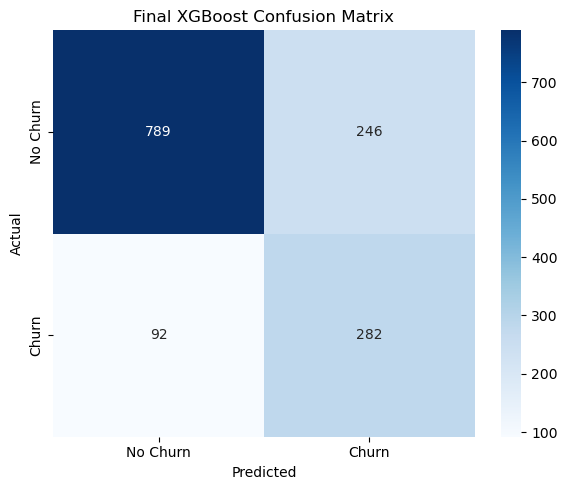

In [144]:
final_cm = confusion_matrix(
    y_test,
    y_pred_xgb_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Final XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [145]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(
    "Model: XGBoost"
)

print(
    "Threshold:",
    round(
        final_threshold,
        3
    )
)

print(
    "ROC-AUC:",
    round(
        final_test_results["ROC_AUC"],
        4
    )
)

print(
    "PR-AUC:",
    round(
        final_test_results["PR_AUC"],
        4
    )
)

print(
    "F1:",
    round(
        final_test_results["F1"],
        4
    )
)

print(
    "Precision:",
    round(
        final_test_results["Precision"],
        4
    )
)

print(
    "Recall:",
    round(
        final_test_results["Recall"],
        4
    )
)

FINAL MODEL SUMMARY
Model: XGBoost
Threshold: 0.54
ROC-AUC: 0.8424
PR-AUC: 0.6558
F1: 0.6253
Precision: 0.5341
Recall: 0.754


In [146]:
final_comparison = results_df.copy()

final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.764372,0.538889,0.778075,0.636761,0.845378,0.662122
1,XGBoost,0.757984,0.529623,0.788770,0.633727,0.842413,0.655821
2,Logistic Regression,0.797729,0.653979,0.505348,0.570136,0.845411,0.651964
3,Random Forest,0.768630,0.548000,0.732620,0.627002,0.842008,0.651626


In [147]:
os.makedirs(
    "reports",
    exist_ok=True
)

final_comparison.to_csv(
    "reports/model_comparison.csv",
    index=False
)

print(
    "Model comparison saved to reports/model_comparison.csv"
)

Model comparison saved to reports/model_comparison.csv


In [148]:
import joblib

print("joblib imported successfully!")

joblib imported successfully!


In [149]:
os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    xgb_model,
    "models/xgboost_churn_pipeline.joblib"
)

print(
    "XGBoost pipeline saved successfully!"
)

XGBoost pipeline saved successfully!


In [150]:
joblib.dump(
    final_threshold,
    "models/churn_threshold.joblib"
)

print(
    "Threshold saved successfully!"
)

Threshold saved successfully!


In [151]:
print(
    "Files inside models folder:"
)

print(
    os.listdir("models")
)

Files inside models folder:
['churn_threshold.joblib', 'model_metadata.json', 'xgboost_churn_pipeline.joblib']


In [152]:
loaded_model = joblib.load(
    "models/xgboost_churn_pipeline.joblib"
)

loaded_threshold = joblib.load(
    "models/churn_threshold.joblib"
)

print(
    "Model loaded successfully!"
)

print(
    "Loaded threshold:",
    loaded_threshold
)

Model loaded successfully!
Loaded threshold: 0.5399999999999998


In [153]:
loaded_probabilities = (
    loaded_model
    .predict_proba(X_test)[:, 1]
)

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)

print(
    "Predictions generated using saved model!"
)

print(
    "First 10 probabilities:"
)

print(
    loaded_probabilities[:10]
)

Predictions generated using saved model!
First 10 probabilities:
[0.02291577 0.9333726  0.20136341 0.5381001  0.00888232 0.8384588
 0.6906455  0.30292585 0.02405334 0.7230013 ]


In [154]:
print(
    "Predictions identical:",
    np.array_equal(
        loaded_predictions,
        y_pred_xgb_final
    )
)

Predictions identical: True


In [155]:
from sklearn.model_selection import StratifiedKFold

catboost_oof_prob = np.zeros(
    len(X_train_cb)
)

catboost_cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train_cb, y_train),
    start=1
):
    
    X_fold_train = X_train_cb.iloc[train_idx]
    X_fold_valid = X_train_cb.iloc[valid_idx]
    
    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]
    
    fold_model = CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        class_weights=[
            1.0,
            scale_pos_weight
        ],
        l2_leaf_reg=5
    )
    
    fold_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=cat_feature_indices
    )
    
    fold_prob = fold_model.predict_proba(
        X_fold_valid
    )[:, 1]
    
    catboost_oof_prob[valid_idx] = fold_prob
    
    fold_auc = roc_auc_score(
        y_fold_valid,
        fold_prob
    )
    
    catboost_cv_scores.append(
        fold_auc
    )
    
    print(
        f"Fold {fold}: ROC-AUC = {fold_auc:.4f}"
    )

print(
    "\nMean ROC-AUC:",
    round(
        np.mean(catboost_cv_scores),
        4
    )
)

Fold 1: ROC-AUC = 0.8400
Fold 2: ROC-AUC = 0.8336
Fold 3: ROC-AUC = 0.8457
Fold 4: ROC-AUC = 0.8635
Fold 5: ROC-AUC = 0.8566

Mean ROC-AUC: 0.8479


In [156]:
catboost_oof_pr_auc = average_precision_score(
    y_train,
    catboost_oof_prob
)

catboost_oof_roc_auc = roc_auc_score(
    y_train,
    catboost_oof_prob
)

print(
    "CatBoost OOF ROC-AUC:",
    round(
        catboost_oof_roc_auc,
        4
    )
)

print(
    "CatBoost OOF PR-AUC:",
    round(
        catboost_oof_pr_auc,
        4
    )
)

CatBoost OOF ROC-AUC: 0.8471
CatBoost OOF PR-AUC: 0.6627


In [157]:
oof_results = pd.DataFrame([
    
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(
            y_train,
            logistic_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            logistic_oof_prob
        )
    },
    
    {
        "Model": "Random Forest",
        "ROC_AUC": roc_auc_score(
            y_train,
            rf_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            rf_oof_prob
        )
    },
    
    {
        "Model": "XGBoost",
        "ROC_AUC": roc_auc_score(
            y_train,
            xgb_oof_prob
        ),
        "PR_AUC": average_precision_score(
            y_train,
            xgb_oof_prob
        )
    },
    
    {
        "Model": "CatBoost",
        "ROC_AUC": catboost_oof_roc_auc,
        "PR_AUC": catboost_oof_pr_auc
    }
])

oof_results = (
    oof_results
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

oof_results

,Model,ROC_AUC,PR_AUC
0,CatBoost,0.847061,0.662694
1,Logistic Regression,0.847005,0.659931
2,Random Forest,0.843834,0.657799
3,XGBoost,0.843557,0.657134


In [158]:
best_model_name = (
    oof_results
    .sort_values(
        by=[
            "PR_AUC",
            "ROC_AUC"
        ],
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Selected model based on OOF performance:",
    best_model_name
)

Selected model based on OOF performance: CatBoost


In [159]:
FN_COST = 1000
FP_COST = 150

print("False Negative Cost:", FN_COST)
print("False Positive Cost:", FP_COST)

False Negative Cost: 1000
False Positive Cost: 150


In [160]:
def calculate_business_cost(
    y_true,
    y_prob,
    threshold,
    fn_cost=1000,
    fp_cost=150
):
    
    y_pred = (
        y_prob >= threshold
    ).astype(int)
    
    cm = confusion_matrix(
        y_true,
        y_pred
    )
    
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = (
        fn * fn_cost
        +
        fp * fp_cost
    )
    
    return {
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Total_Cost": total_cost
    }

In [161]:
business_thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

business_results = []

for threshold in business_thresholds:
    
    result = calculate_business_cost(
        y_test,
        y_prob_xgb,
        threshold,
        FN_COST,
        FP_COST
    )
    
    business_results.append(result)

business_cost_df = pd.DataFrame(
    business_results
)

business_cost_df.head()

,Threshold,TN,FP,FN,TP,Total_Cost
0,0.10,388,647,13,361,110050
1,0.11,407,628,14,360,108200
2,0.12,419,616,16,358,108400
3,0.13,434,601,17,357,107150
4,0.14,449,586,18,356,105900


In [162]:
business_cost_df.sort_values(
    "Total_Cost"
).head(10)

,Threshold,TN,FP,FN,TP,Total_Cost
13,0.23,554,481,26,348,98150
12,0.22,547,488,25,349,98200
8,0.18,505,530,19,355,98500
9,0.19,517,518,21,353,98700
21,0.31,643,392,40,334,98800
23,0.33,655,380,42,332,99000
10,0.20,527,508,23,351,99200
17,0.27,599,436,34,340,99400
14,0.24,564,471,29,345,99650
11,0.21,535,500,25,349,100000


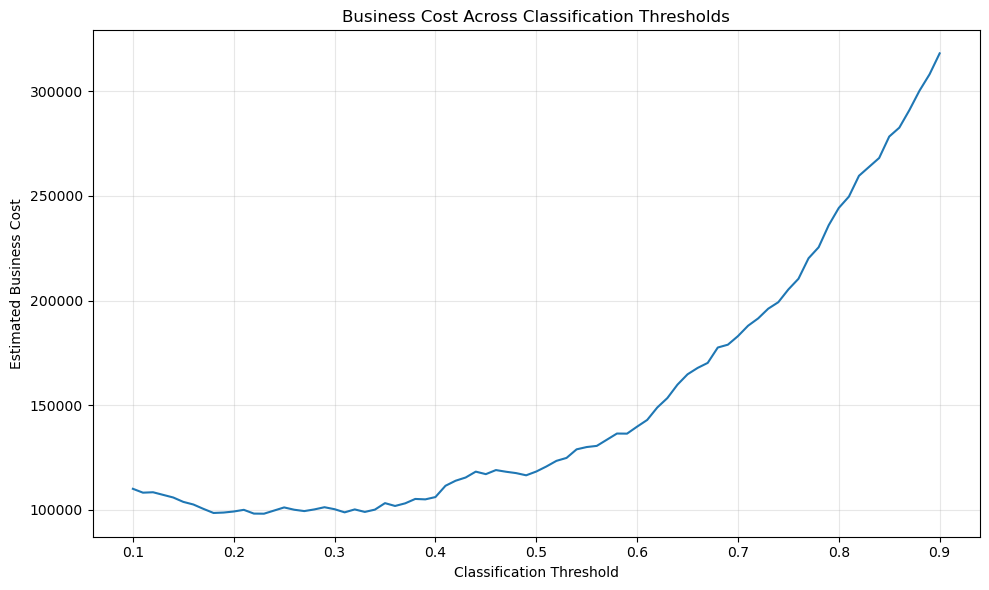

In [163]:
plt.figure(figsize=(10, 6))

plt.plot(
    business_cost_df["Threshold"],
    business_cost_df["Total_Cost"]
)

plt.xlabel("Classification Threshold")
plt.ylabel("Estimated Business Cost")
plt.title("Business Cost Across Classification Thresholds")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [164]:
top_k_business = top_k_capture(
    y_test,
    y_prob_xgb,
    k_values=np.arange(
        5,
        51,
        5
    )
)

top_k_business

,Top_%_Customers,Customers_Targeted,Churners_Captured,Capture_Rate_%
0,5,70,56,14.973262
1,10,140,106,28.342246
2,15,211,151,40.374332
3,20,281,190,50.802139
4,25,352,216,57.754011
5,30,422,247,66.042781
6,35,493,271,72.459893
7,40,563,297,79.411765
8,45,634,309,82.620321
9,50,704,330,88.235294


In [165]:
top_k_business["Targeted_Customer_%"] = (
    top_k_business["Top_%_Customers"]
)

top_k_business[
    [
        "Targeted_Customer_%",
        "Customers_Targeted",
        "Churners_Captured",
        "Capture_Rate_%"
    ]
]

,Targeted_Customer_%,Customers_Targeted,Churners_Captured,Capture_Rate_%
0,5,70,56,14.973262
1,10,140,106,28.342246
2,15,211,151,40.374332
3,20,281,190,50.802139
4,25,352,216,57.754011
5,30,422,247,66.042781
6,35,493,271,72.459893
7,40,563,297,79.411765
8,45,634,309,82.620321
9,50,704,330,88.235294


In [166]:
def assign_risk_level(probability):
    
    if probability < 0.30:
        return "Low Risk"
    
    elif probability < 0.60:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [167]:
final_risk_output = X_test.copy()

final_risk_output["Churn_Probability"] = (
    y_prob_xgb
)

final_risk_output["Risk_Level"] = (
    final_risk_output[
        "Churn_Probability"
    ]
    .apply(assign_risk_level)
)

final_risk_output.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,AverageMonthlySpend,TenureGroup,Churn_Probability,Risk_Level
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Two year,Yes,Credit card (automatic),114.05,8468.20,8,117.613889,49+ Months,0.022916,Low Risk
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Credit card (automatic),100.15,908.55,5,113.568750,7-12 Months,0.933373,High Risk
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,One year,Yes,Credit card (automatic),78.35,3211.20,6,78.321951,25-48 Months,0.201363,Low Risk
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,78.20,1468.75,3,81.597222,13-24 Months,0.538100,Medium Risk
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Two year,Yes,Credit card (automatic),82.65,5919.35,7,82.213194,49+ Months,0.008882,Low Risk


In [168]:
risk_distribution = (
    final_risk_output[
        "Risk_Level"
    ]
    .value_counts()
)

risk_distribution

Risk_Level
Low Risk       673
High Risk      470
Medium Risk    266
Name: count, dtype: int64

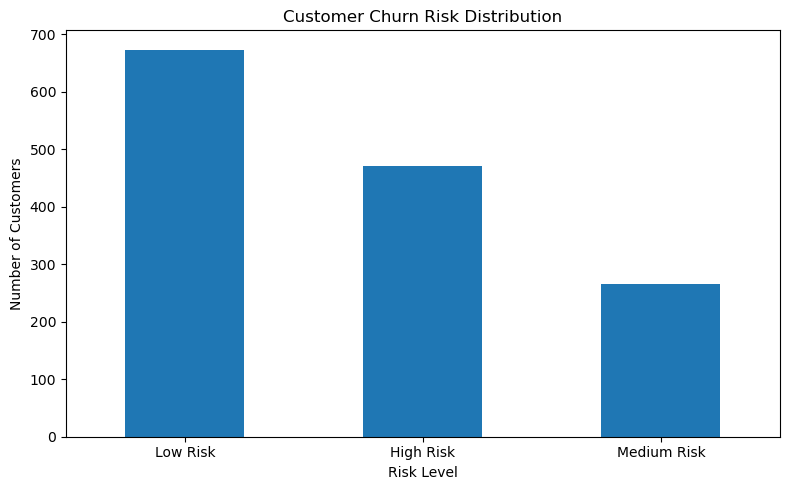

In [169]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(
    kind="bar"
)

plt.title(
    "Customer Churn Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [170]:
def retention_action(risk_level):
    
    if risk_level == "High Risk":
        return "Immediate retention intervention"
    
    elif risk_level == "Medium Risk":
        return "Proactive engagement"
    
    else:
        return "Routine engagement"

In [171]:
final_risk_output["Recommended_Action"] = (
    final_risk_output[
        "Risk_Level"
    ]
    .apply(retention_action)
)

final_risk_output[
    [
        "Churn_Probability",
        "Risk_Level",
        "Recommended_Action"
    ]
].head(20)

,Churn_Probability,Risk_Level,Recommended_Action
437,0.022916,Low Risk,Routine engagement
2280,0.933373,High Risk,Immediate retention intervention
2235,0.201363,Low Risk,Routine engagement
4460,0.538100,Medium Risk,Proactive engagement
3761,0.008882,Low Risk,Routine engagement
5748,0.838459,High Risk,Immediate retention intervention
3568,0.690646,High Risk,Immediate retention intervention
2976,0.302926,Medium Risk,Proactive engagement
5928,0.024053,Low Risk,Routine engagement
1639,0.723001,High Risk,Immediate retention intervention


In [172]:
def predict_customer_churn(
    customer_data,
    model,
    threshold=0.50
):
    
    probability = model.predict_proba(
        customer_data
    )[:, 1]
    
    prediction = (
        probability >= threshold
    ).astype(int)
    
    risk_levels = [
        assign_risk_level(p)
        for p in probability
    ]
    
    actions = [
        retention_action(risk)
        for risk in risk_levels
    ]
    
    result = customer_data.copy()
    
    result["Churn_Probability"] = probability
    
    result["Churn_Prediction"] = prediction
    
    result["Risk_Level"] = risk_levels
    
    result["Recommended_Action"] = actions
    
    return result

In [173]:
sample_customer = X_test.iloc[
    [0]
].copy()

prediction_result = predict_customer_churn(
    sample_customer,
    loaded_model,
    loaded_threshold
)

prediction_result[
    [
        "Churn_Probability",
        "Churn_Prediction",
        "Risk_Level",
        "Recommended_Action"
    ]
]

,Churn_Probability,Churn_Prediction,Risk_Level,Recommended_Action
437,0.022916,0,Low Risk,Routine engagement


In [174]:
def predict_batch(
    customer_dataframe,
    model,
    threshold
):
    
    probabilities = (
        model.predict_proba(
            customer_dataframe
        )[:, 1]
    )
    
    predictions = (
        probabilities >= threshold
    ).astype(int)
    
    output = customer_dataframe.copy()
    
    output["Churn_Probability"] = (
        probabilities
    )
    
    output["Churn_Prediction"] = (
        predictions
    )
    
    output["Risk_Level"] = [
        assign_risk_level(p)
        for p in probabilities
    ]
    
    output["Recommended_Action"] = [
        retention_action(r)
        for r in output["Risk_Level"]
    ]
    
    return output

In [175]:
batch_result = predict_batch(
    X_test.head(10),
    loaded_model,
    loaded_threshold
)

batch_result[
    [
        "Churn_Probability",
        "Churn_Prediction",
        "Risk_Level",
        "Recommended_Action"
    ]
]

,Churn_Probability,Churn_Prediction,Risk_Level,Recommended_Action
437,0.022916,0,Low Risk,Routine engagement
2280,0.933373,1,High Risk,Immediate retention intervention
2235,0.201363,0,Low Risk,Routine engagement
4460,0.538100,0,Medium Risk,Proactive engagement
3761,0.008882,0,Low Risk,Routine engagement
5748,0.838459,1,High Risk,Immediate retention intervention
3568,0.690646,1,High Risk,Immediate retention intervention
2976,0.302926,0,Medium Risk,Proactive engagement
5928,0.024053,0,Low Risk,Routine engagement
1639,0.723001,1,High Risk,Immediate retention intervention


In [176]:
os.makedirs(
    "reports",
    exist_ok=True
)

batch_result.to_csv(
    "reports/sample_predictions.csv",
    index=False
)

print(
    "Sample predictions exported successfully!"
)

Sample predictions exported successfully!


In [177]:
import json

model_metadata = {
    "model_name": "XGBoost",
    "threshold": float(final_threshold),
    "primary_metric": "PR-AUC",
    "secondary_metrics": [
        "ROC-AUC",
        "F1",
        "Precision",
        "Recall"
    ],
    "random_state": 42,
    "project": "Customer Churn Prediction"
}

with open(
    "models/model_metadata.json",
    "w"
) as file:
    
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print(
    "Model metadata saved!"
)

Model metadata saved!


In [178]:
catboost_oof_thresholds = evaluate_thresholds(
    y_train,
    catboost_oof_prob
)

catboost_oof_thresholds.head()

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
0,0.10,0.355755,0.979933,0.522002,0.730919
1,0.11,0.360631,0.977926,0.526942,0.719560
2,0.12,0.365187,0.973913,0.531193,0.707668
3,0.13,0.371108,0.972575,0.537225,0.695421
4,0.14,0.375032,0.970569,0.541014,0.686723


In [179]:
catboost_best_threshold = (
    catboost_oof_thresholds
    .loc[
        catboost_oof_thresholds["F1"].idxmax(),
        "Threshold"
    ]
)

print(
    "CatBoost OOF optimal threshold:",
    round(
        catboost_best_threshold,
        3
    )
)

CatBoost OOF optimal threshold: 0.54


In [180]:
catboost_threshold_summary = (
    catboost_oof_thresholds
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)
)

catboost_threshold_summary

,Threshold,Precision,Recall,F1,Predicted_Churn_Rate
44,0.54,0.559043,0.750502,0.640777,0.356230
49,0.59,0.588764,0.701003,0.640000,0.315939
48,0.58,0.579521,0.711706,0.638847,0.325879
43,0.53,0.550971,0.759197,0.638537,0.365637
45,0.55,0.562404,0.738462,0.638519,0.348420
46,0.56,0.566615,0.731104,0.638435,0.342386
47,0.57,0.572187,0.721070,0.638059,0.334398
42,0.52,0.545931,0.767224,0.637931,0.372914
50,0.60,0.593985,0.686957,0.637097,0.306887
41,0.51,0.540907,0.773913,0.636764,0.379659


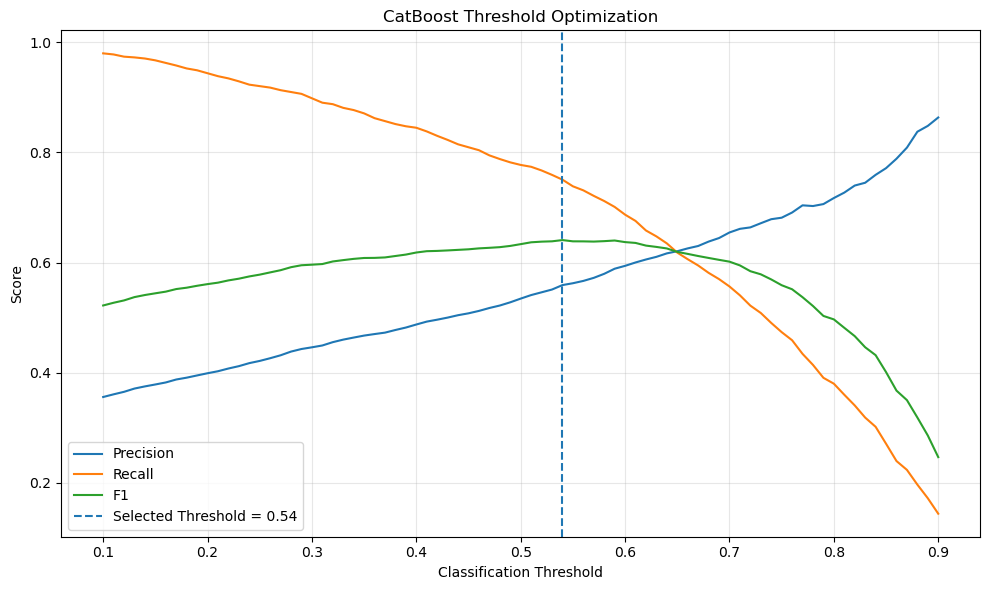

In [181]:
plt.figure(figsize=(10, 6))

plt.plot(
    catboost_oof_thresholds["Threshold"],
    catboost_oof_thresholds["Precision"],
    label="Precision"
)

plt.plot(
    catboost_oof_thresholds["Threshold"],
    catboost_oof_thresholds["Recall"],
    label="Recall"
)

plt.plot(
    catboost_oof_thresholds["Threshold"],
    catboost_oof_thresholds["F1"],
    label="F1"
)

plt.axvline(
    catboost_best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {catboost_best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("CatBoost Threshold Optimization")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [182]:
catboost_final_test_pred = (
    y_prob_cb >= catboost_best_threshold
).astype(int)

print(
    "Final CatBoost test predictions generated!"
)

Final CatBoost test predictions generated!


In [183]:
catboost_final_results = evaluate_model(
    "CatBoost - Optimized Threshold",
    y_test,
    catboost_final_test_pred,
    y_prob_cb
)

pd.DataFrame([
    catboost_final_results
])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost - Optimized Threshold,0.772889,0.55336,0.748663,0.636364,0.845378,0.662122


In [184]:
print(
    classification_report(
        y_test,
        catboost_final_test_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.78      0.83      1035
       Churn       0.55      0.75      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.80      0.77      0.78      1409



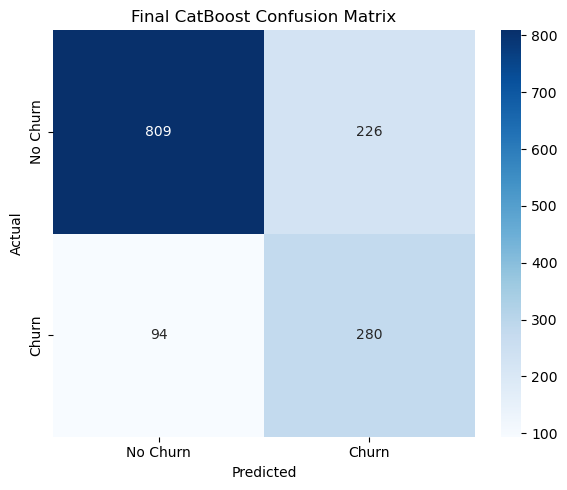

In [185]:
catboost_final_cm = confusion_matrix(
    y_test,
    catboost_final_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    catboost_final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Final CatBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [186]:
final_model_comparison = pd.DataFrame([
    
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob_logistic
        ),
        "PR_AUC": average_precision_score(
            y_test,
            y_prob_logistic
        ),
        "F1_Default": f1_score(
            y_test,
            y_pred_logistic
        )
    },
    
    {
        "Model": "Random Forest",
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob_rf
        ),
        "PR_AUC": average_precision_score(
            y_test,
            y_prob_rf
        ),
        "F1_Default": f1_score(
            y_test,
            y_pred_rf
        )
    },
    
    {
        "Model": "XGBoost",
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob_xgb
        ),
        "PR_AUC": average_precision_score(
            y_test,
            y_prob_xgb
        ),
        "F1_Default": f1_score(
            y_test,
            y_pred_xgb
        )
    },
    
    {
        "Model": "CatBoost",
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob_cb
        ),
        "PR_AUC": average_precision_score(
            y_test,
            y_prob_cb
        ),
        "F1_Default": f1_score(
            y_test,
            y_pred_cb
        ),
        "F1_Optimized": f1_score(
            y_test,
            catboost_final_test_pred
        )
    }
])

final_model_comparison

,Model,ROC_AUC,PR_AUC,F1_Default,F1_Optimized
0,Logistic Regression,0.845411,0.651964,0.570136,NaN
1,Random Forest,0.842008,0.651626,0.627002,NaN
2,XGBoost,0.842413,0.655821,0.633727,NaN
3,CatBoost,0.845378,0.662122,0.636761,0.636364


In [187]:
def assign_risk_level(probability):
    
    if probability < 0.30:
        return "Low Risk"
    
    elif probability < 0.60:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [188]:
def retention_action(risk_level):
    
    if risk_level == "High Risk":
        return "Immediate retention intervention"
    
    elif risk_level == "Medium Risk":
        return "Proactive engagement"
    
    else:
        return "Routine engagement"

In [189]:
final_risk_output = X_test_cb.copy()

final_risk_output["Churn_Probability"] = y_prob_cb

final_risk_output["Churn_Prediction"] = (
    catboost_final_test_pred
)

final_risk_output["Risk_Level"] = (
    final_risk_output[
        "Churn_Probability"
    ]
    .apply(assign_risk_level)
)

final_risk_output["Recommended_Action"] = (
    final_risk_output[
        "Risk_Level"
    ]
    .apply(retention_action)
)

final_risk_output.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,AverageMonthlySpend,TenureGroup,Churn_Probability,Churn_Prediction,Risk_Level,Recommended_Action
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Credit card (automatic),114.05,8468.20,8,117.613889,49+ Months,0.046379,0,Low Risk,Routine engagement
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Credit card (automatic),100.15,908.55,5,113.568750,7-12 Months,0.906015,1,High Risk,Immediate retention intervention
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Credit card (automatic),78.35,3211.20,6,78.321951,25-48 Months,0.149908,0,Low Risk,Routine engagement
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Electronic check,78.20,1468.75,3,81.597222,13-24 Months,0.552608,1,Medium Risk,Proactive engagement
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Credit card (automatic),82.65,5919.35,7,82.213194,49+ Months,0.021570,0,Low Risk,Routine engagement
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Credit card (automatic),99.85,1992.55,5,94.883333,13-24 Months,0.795953,1,High Risk,Immediate retention intervention
3568,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,...,Bank transfer (automatic),99.15,1956.40,5,93.161905,13-24 Months,0.643527,1,High Risk,Immediate retention intervention
2976,Male,0,No,Yes,19,Yes,Yes,No,No internet service,No internet service,...,Credit card (automatic),24.10,439.20,2,23.115789,13-24 Months,0.254218,0,Low Risk,Routine engagement
5928,Female,0,Yes,Yes,61,Yes,No,No,No internet service,No internet service,...,Credit card (automatic),19.75,1311.60,1,21.501639,49+ Months,0.018272,0,Low Risk,Routine engagement
1639,Male,1,No,No,17,Yes,No,DSL,No,No,...,Electronic check,45.05,770.60,1,45.329412,13-24 Months,0.620941,1,High Risk,Immediate retention intervention


In [190]:
risk_distribution = (
    final_risk_output[
        "Risk_Level"
    ]
    .value_counts()
)

risk_distribution

Risk_Level
Low Risk       655
High Risk      443
Medium Risk    311
Name: count, dtype: int64

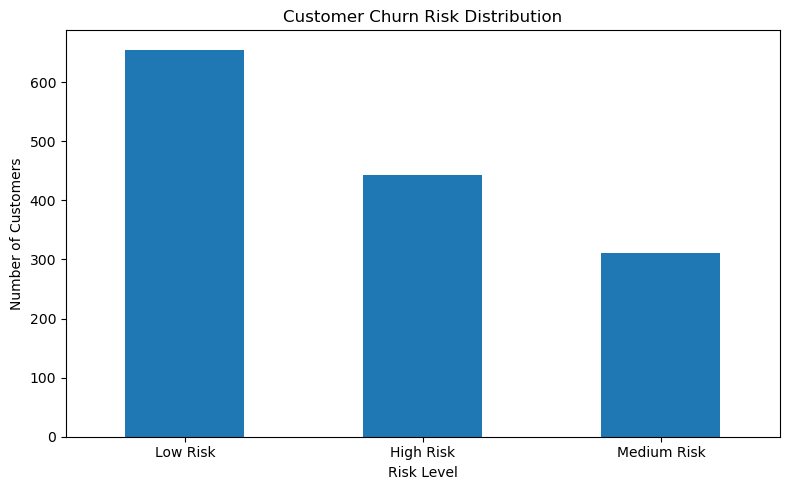

In [191]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(
    kind="bar"
)

plt.title(
    "Customer Churn Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [192]:
top_high_risk = (
    final_risk_output
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(20)
)

top_high_risk[
    [
        "Churn_Probability",
        "Churn_Prediction",
        "Risk_Level",
        "Recommended_Action"
    ]
]

,Churn_Probability,Churn_Prediction,Risk_Level,Recommended_Action
3380,0.965155,1,High Risk,Immediate retention intervention
6866,0.965060,1,High Risk,Immediate retention intervention
4585,0.952671,1,High Risk,Immediate retention intervention
4678,0.949953,1,High Risk,Immediate retention intervention
383,0.948558,1,High Risk,Immediate retention intervention
2797,0.944301,1,High Risk,Immediate retention intervention
3727,0.943247,1,High Risk,Immediate retention intervention
2753,0.941662,1,High Risk,Immediate retention intervention
6623,0.940887,1,High Risk,Immediate retention intervention
3346,0.938564,1,High Risk,Immediate retention intervention


In [193]:
catboost_explainer = shap.TreeExplainer(
    catboost_model
)

catboost_shap_values = (
    catboost_explainer.shap_values(
        X_test_cb
    )
)

print(
    "CatBoost SHAP values generated!"
)

CatBoost SHAP values generated!


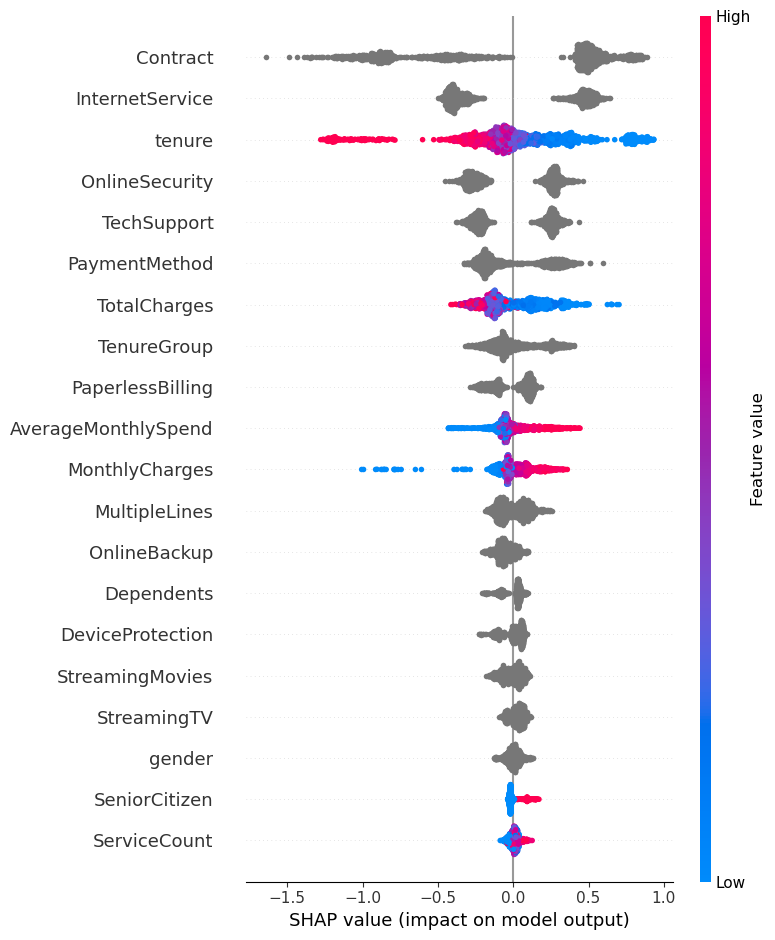

In [194]:
shap.summary_plot(
    catboost_shap_values,
    X_test_cb,
    feature_names=X_test_cb.columns,
    show=True
)

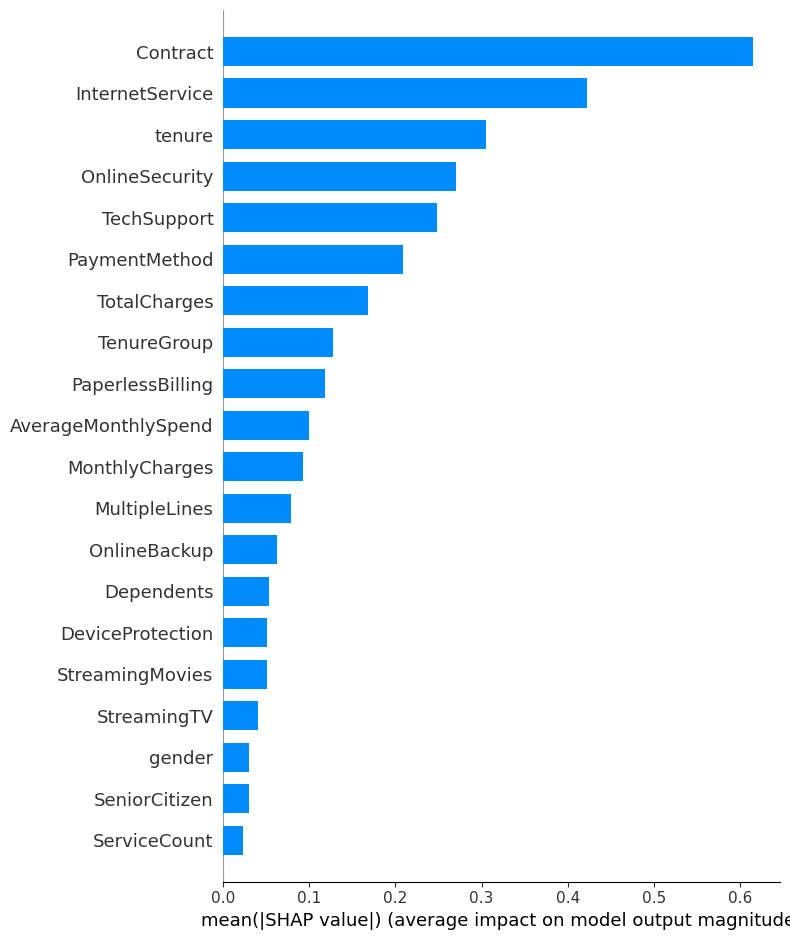

In [195]:
shap.summary_plot(
    catboost_shap_values,
    X_test_cb,
    feature_names=X_test_cb.columns,
    plot_type="bar",
    show=True
)

In [196]:
customer_index = 0

print(
    "Customer index:",
    customer_index
)

print(
    "Actual churn:",
    y_test.iloc[customer_index]
)

print(
    "Predicted probability:",
    round(
        y_prob_cb[customer_index],
        4
    )
)

print(
    "Risk level:",
    assign_risk_level(
        y_prob_cb[customer_index]
    )
)

Customer index: 0
Actual churn: 0
Predicted probability: 0.0464
Risk level: Low Risk


In [197]:
X_test_cb.iloc[
    [customer_index]
].T

,437
gender,Male
SeniorCitizen,0
Partner,Yes
Dependents,Yes
tenure,72
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,Yes
OnlineBackup,Yes


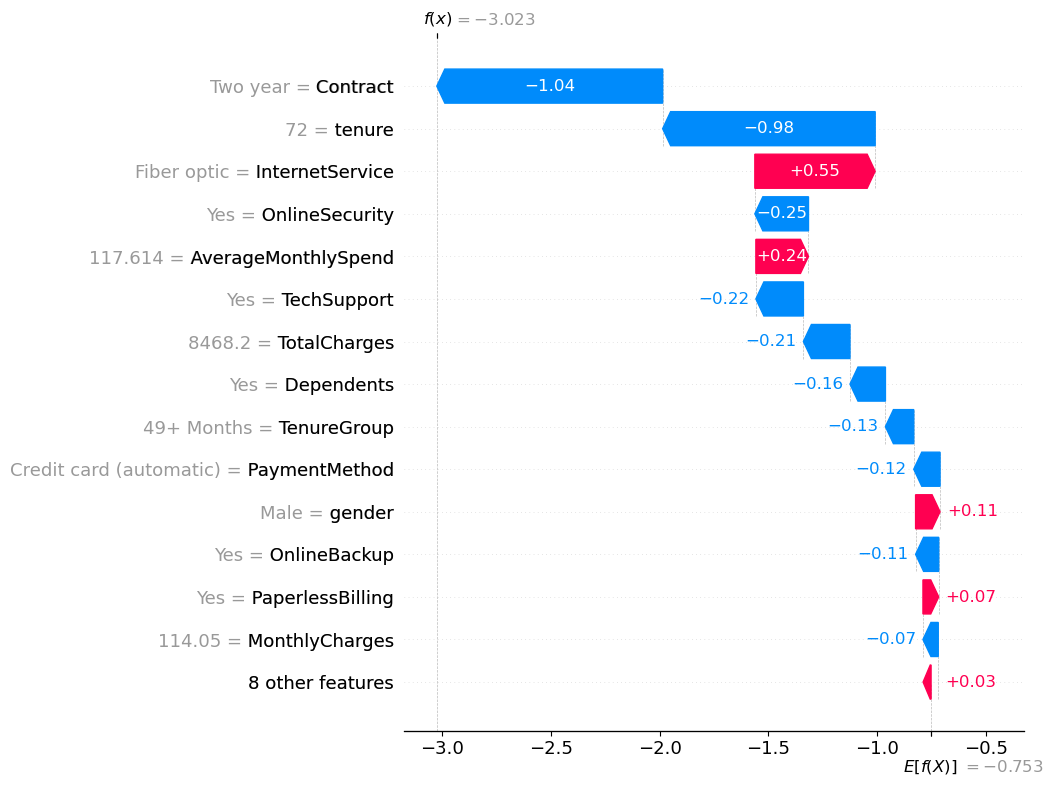

In [198]:
shap.waterfall_plot(
    shap.Explanation(
        values=catboost_shap_values[
            customer_index
        ],
        base_values=(
            catboost_explainer.expected_value
            if np.isscalar(
                catboost_explainer.expected_value
            )
            else catboost_explainer.expected_value[0]
        ),
        data=X_test_cb.iloc[
            customer_index
        ].values,
        feature_names=X_test_cb.columns
    ),
    max_display=15
)

In [199]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

print(
    "Models directory ready!"
)

Models directory ready!


In [200]:
catboost_model.save_model(
    "models/catboost_churn_model.cbm"
)

print(
    "CatBoost model saved successfully!"
)

CatBoost model saved successfully!


In [201]:
joblib.dump(
    catboost_best_threshold,
    "models/catboost_threshold.joblib"
)

print(
    "CatBoost threshold saved successfully!"
)

CatBoost threshold saved successfully!


In [202]:
feature_metadata = {
    "features": list(X_train_cb.columns),
    "categorical_features": list(categorical_features)
}

with open(
    "models/feature_metadata.json",
    "w"
) as file:
    
    json.dump(
        feature_metadata,
        file,
        indent=4
    )

print(
    "Feature metadata saved successfully!"
)

Feature metadata saved successfully!


In [203]:
final_model_metadata = {
    "model_name": "CatBoost",
    "model_file": "catboost_churn_model.cbm",
    "threshold_file": "catboost_threshold.joblib",
    "primary_metric": "PR-AUC",
    "selection_method": "OOF PR-AUC",
    "threshold_selection": "OOF F1 optimization",
    "threshold": float(
        catboost_best_threshold
    ),
    "random_state": 42
}

with open(
    "models/model_metadata.json",
    "w"
) as file:
    
    json.dump(
        final_model_metadata,
        file,
        indent=4
    )

print(
    "Final model metadata saved!"
)

Final model metadata saved!


In [204]:
print(
    os.listdir("models")
)

['catboost_churn_model.cbm', 'catboost_threshold.joblib', 'churn_threshold.joblib', 'feature_metadata.json', 'model_metadata.json', 'xgboost_churn_pipeline.joblib']


In [205]:
loaded_catboost = CatBoostClassifier()

loaded_catboost.load_model(
    "models/catboost_churn_model.cbm"
)

print(
    "Saved CatBoost model loaded successfully!"
)

Saved CatBoost model loaded successfully!


In [206]:
loaded_catboost_prob = (
    loaded_catboost
    .predict_proba(X_test_cb)[:, 1]
)

print(
    "Original probability:",
    y_prob_cb[:5]
)

print(
    "\nLoaded model probability:",
    loaded_catboost_prob[:5]
)

Original probability: [0.04637931 0.90601477 0.1499082  0.55260785 0.02156959]

Loaded model probability: [0.04637931 0.90601477 0.1499082  0.55260785 0.02156959]


In [207]:
print(
    "Predictions match:",
    np.allclose(
        y_prob_cb,
        loaded_catboost_prob
    )
)

Predictions match: True


In [208]:
os.makedirs(
    "reports",
    exist_ok=True
)

final_model_comparison.to_csv(
    "reports/final_model_comparison.csv",
    index=False
)

final_risk_output.to_csv(
    "reports/final_customer_risk_predictions.csv",
    index=False
)

catboost_oof_thresholds.to_csv(
    "reports/catboost_threshold_analysis.csv",
    index=False
)

print(
    "Final reports exported successfully!"
)

Final reports exported successfully!


In [209]:
print("=" * 65)
print("CUSTOMER CHURN PROJECT — FINAL SUMMARY")
print("=" * 65)

print(
    "\nSelected Model:",
    "CatBoost"
)

print(
    "OOF PR-AUC:",
    round(
        catboost_oof_pr_auc,
        4
    )
)

print(
    "Test PR-AUC:",
    round(
        catboost_final_results["PR_AUC"],
        4
    )
)

print(
    "Test ROC-AUC:",
    round(
        catboost_final_results["ROC_AUC"],
        4
    )
)

print(
    "Optimized Threshold:",
    round(
        catboost_best_threshold,
        3
    )
)

print(
    "Test F1:",
    round(
        catboost_final_results["F1"],
        4
    )
)

print(
    "Test Precision:",
    round(
        catboost_final_results["Precision"],
        4
    )
)

print(
    "Test Recall:",
    round(
        catboost_final_results["Recall"],
        4
    )
)

print("=" * 65)

CUSTOMER CHURN PROJECT — FINAL SUMMARY

Selected Model: CatBoost
OOF PR-AUC: 0.6627
Test PR-AUC: 0.6621
Test ROC-AUC: 0.8454
Optimized Threshold: 0.54
Test F1: 0.6364
Test Precision: 0.5534
Test Recall: 0.7487


In [210]:
feature_schema = {}

for column in X_train_cb.columns:
    
    if column in categorical_features:
        feature_type = "categorical"
        
        values = (
            X_train_cb[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        
        default_value = str(
            X_train_cb[column]
            .mode()[0]
        )
        
        feature_schema[column] = {
            "type": feature_type,
            "values": values,
            "default": default_value
        }
        
    else:
        feature_type = "numeric"
        
        numeric_series = pd.to_numeric(
            X_train_cb[column],
            errors="coerce"
        )
        
        feature_schema[column] = {
            "type": feature_type,
            "min": float(
                numeric_series.min()
            ),
            "max": float(
                numeric_series.max()
            ),
            "default": float(
                numeric_series.median()
            )
        }

print(
    "Feature schema created for",
    len(feature_schema),
    "features."
)

Feature schema created for 22 features.


In [211]:
with open(
    "models/feature_schema.json",
    "w"
) as file:
    
    json.dump(
        feature_schema,
        file,
        indent=4
    )

print(
    "Feature schema saved successfully!"
)

Feature schema saved successfully!


In [212]:
os.makedirs(
    "src",
    exist_ok=True
)

os.makedirs(
    "notebooks",
    exist_ok=True
)

os.makedirs(
    "data",
    exist_ok=True
)

os.makedirs(
    "reports",
    exist_ok=True
)

print("Project directories created!")

Project directories created!


In [213]:
%%writefile src/predictor.py

import json
import joblib
import pandas as pd
from pathlib import Path
from catboost import CatBoostClassifier


BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    BASE_DIR
    / "models"
    / "catboost_churn_model.cbm"
)

THRESHOLD_PATH = (
    BASE_DIR
    / "models"
    / "catboost_threshold.joblib"
)

SCHEMA_PATH = (
    BASE_DIR
    / "models"
    / "feature_schema.json"
)

METADATA_PATH = (
    BASE_DIR
    / "models"
    / "model_metadata.json"
)


def load_model():
    
    model = CatBoostClassifier()
    
    model.load_model(
        str(MODEL_PATH)
    )
    
    return model


def load_threshold():
    
    return joblib.load(
        THRESHOLD_PATH
    )


def load_schema():
    
    with open(
        SCHEMA_PATH,
        "r"
    ) as file:
        
        return json.load(file)


def load_metadata():
    
    with open(
        METADATA_PATH,
        "r"
    ) as file:
        
        return json.load(file)


def assign_risk(probability):
    
    if probability < 0.30:
        return "Low Risk"
    
    elif probability < 0.60:
        return "Medium Risk"
    
    return "High Risk"


def get_recommendation(risk):
    
    if risk == "High Risk":
        return "Immediate retention intervention"
    
    elif risk == "Medium Risk":
        return "Proactive engagement"
    
    return "Routine engagement"


def predict_dataframe(df):
    
    model = load_model()
    threshold = load_threshold()
    
    probability = (
        model.predict_proba(df)[:, 1]
    )
    
    prediction = (
        probability >= threshold
    ).astype(int)
    
    result = df.copy()
    
    result["Churn_Probability"] = probability
    
    result["Churn_Prediction"] = prediction
    
    result["Risk_Level"] = [
        assign_risk(p)
        for p in probability
    ]
    
    result["Recommended_Action"] = [
        get_recommendation(r)
        for r in result["Risk_Level"]
    ]
    
    return result


def predict_single(df):
    
    result = predict_dataframe(df)
    
    return result.iloc[0]

Writing src/predictor.py


In [214]:
from src.predictor import (
    predict_dataframe,
    predict_single,
    load_model,
    load_threshold,
    load_schema
)

print("Predictor module imported successfully!")

Predictor module imported successfully!


In [215]:
test_prediction = predict_dataframe(
    X_test_cb.head(5)
)

test_prediction[
    [
        "Churn_Probability",
        "Churn_Prediction",
        "Risk_Level",
        "Recommended_Action"
    ]
]

,Churn_Probability,Churn_Prediction,Risk_Level,Recommended_Action
437,0.046379,0,Low Risk,Routine engagement
2280,0.906015,1,High Risk,Immediate retention intervention
2235,0.149908,0,Low Risk,Routine engagement
4460,0.552608,1,Medium Risk,Proactive engagement
3761,0.021570,0,Low Risk,Routine engagement


In [216]:
%%writefile app.py

import sys
from pathlib import Path

import streamlit as st
import pandas as pd
import numpy as np
import json

import plotly.express as px


BASE_DIR = Path(__file__).resolve().parent

sys.path.append(
    str(BASE_DIR)
)

from src.predictor import (
    predict_dataframe,
    predict_single,
    load_model,
    load_threshold,
    load_schema,
    load_metadata
)


# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Customer Churn Intelligence",
    page_icon="📊",
    layout="wide"
)


# --------------------------------------------------
# LOAD RESOURCES
# --------------------------------------------------

@st.cache_resource
def get_model():
    return load_model()


@st.cache_data
def get_schema():
    return load_schema()


@st.cache_data
def get_metadata():
    return load_metadata()


model = get_model()
schema = get_schema()
metadata = get_metadata()

threshold = load_threshold()


# --------------------------------------------------
# HEADER
# --------------------------------------------------

st.title(
    "📊 Customer Churn Intelligence"
)

st.markdown(
    """
    **Machine Learning powered customer churn prediction
    and retention prioritization system.**
    """
)

st.divider()


# --------------------------------------------------
# SIDEBAR
# --------------------------------------------------

st.sidebar.title(
    "Navigation"
)

page = st.sidebar.radio(
    "Select Module",
    [
        "Dashboard",
        "Single Customer",
        "Batch Prediction",
        "Model Information"
    ]
)


# ==================================================
# DASHBOARD
# ==================================================

if page == "Dashboard":

    st.header(
        "Customer Churn Dashboard"
    )

    st.info(
        "Upload a customer CSV to generate "
        "churn analytics."
    )

    uploaded_file = st.file_uploader(
        "Upload Customer CSV",
        type=["csv"]
    )

    if uploaded_file is not None:

        df = pd.read_csv(
            uploaded_file
        )

        st.subheader(
            "Uploaded Dataset"
        )

        st.dataframe(
            df.head(10),
            use_container_width=True
        )

        try:

            predictions = predict_dataframe(
                df
            )

            total_customers = len(
                predictions
            )

            predicted_churners = int(
                predictions[
                    "Churn_Prediction"
                ].sum()
            )

            high_risk = int(
                (
                    predictions[
                        "Risk_Level"
                    ]
                    == "High Risk"
                ).sum()
            )

            avg_probability = (
                predictions[
                    "Churn_Probability"
                ].mean()
            )

            col1, col2, col3, col4 = st.columns(4)

            col1.metric(
                "Total Customers",
                total_customers
            )

            col2.metric(
                "Predicted Churners",
                predicted_churners
            )

            col3.metric(
                "High Risk Customers",
                high_risk
            )

            col4.metric(
                "Average Churn Probability",
                f"{avg_probability:.1%}"
            )

            st.divider()

            col1, col2 = st.columns(2)

            with col1:

                risk_counts = (
                    predictions[
                        "Risk_Level"
                    ]
                    .value_counts()
                    .reset_index()
                )

                risk_counts.columns = [
                    "Risk_Level",
                    "Customers"
                ]

                fig = px.bar(
                    risk_counts,
                    x="Risk_Level",
                    y="Customers",
                    title="Risk Distribution"
                )

                st.plotly_chart(
                    fig,
                    use_container_width=True
                )

            with col2:

                probability_fig = px.histogram(
                    predictions,
                    x="Churn_Probability",
                    nbins=20,
                    title="Churn Probability Distribution"
                )

                st.plotly_chart(
                    probability_fig,
                    use_container_width=True
                )

            st.subheader(
                "Highest Risk Customers"
            )

            high_risk_customers = (
                predictions
                .sort_values(
                    "Churn_Probability",
                    ascending=False
                )
                .head(20)
            )

            st.dataframe(
                high_risk_customers,
                use_container_width=True
            )

            csv_data = predictions.to_csv(
                index=False
            )

            st.download_button(
                "⬇️ Download Predictions",
                data=csv_data,
                file_name="churn_predictions.csv",
                mime="text/csv"
            )

        except Exception as e:

            st.error(
                f"Prediction failed: {e}"
            )


# ==================================================
# SINGLE CUSTOMER
# ==================================================

elif page == "Single Customer":

    st.header(
        "Single Customer Prediction"
    )

    st.write(
        "Enter customer information below."
    )

    user_data = {}

    columns = list(
        schema.keys()
    )

    for column in columns:

        info = schema[column]

        if info["type"] == "categorical":

            options = info.get(
                "values",
                []
            )

            default = info.get(
                "default"
            )

            if default in options:
                default_index = (
                    options.index(default)
                )
            else:
                default_index = 0

            user_data[column] = st.selectbox(
                column,
                options,
                index=default_index
            )

        else:

            minimum = info["min"]
            maximum = info["max"]
            default = info["default"]

            user_data[column] = st.number_input(
                column,
                min_value=float(minimum),
                max_value=float(maximum),
                value=float(default)
            )

    if st.button(
        "🔍 Predict Churn",
        type="primary"
    ):

        input_df = pd.DataFrame(
            [user_data]
        )

        try:

            result = predict_single(
                input_df
            )

            probability = float(
                result[
                    "Churn_Probability"
                ]
            )

            risk = result[
                "Risk_Level"
            ]

            action = result[
                "Recommended_Action"
            ]

            st.divider()

            col1, col2, col3 = st.columns(3)

            col1.metric(
                "Churn Probability",
                f"{probability:.1%}"
            )

            col2.metric(
                "Risk Level",
                risk
            )

            col3.metric(
                "Prediction",
                "Churn" if result[
                    "Churn_Prediction"
                ] == 1 else "No Churn"
            )

            st.success(
                f"Recommended Action: {action}"
            )

        except Exception as e:

            st.error(
                f"Prediction failed: {e}"
            )


# ==================================================
# BATCH PREDICTION
# ==================================================

elif page == "Batch Prediction":

    st.header(
        "Batch Customer Prediction"
    )

    st.write(
        "Upload a CSV containing the same "
        "input features used during training."
    )

    uploaded_file = st.file_uploader(
        "Upload CSV",
        type=["csv"],
        key="batch"
    )

    if uploaded_file is not None:

        df = pd.read_csv(
            uploaded_file
        )

        required_columns = list(
            schema.keys()
        )

        missing_columns = [
            column
            for column in required_columns
            if column not in df.columns
        ]

        if missing_columns:

            st.error(
                "Missing required columns:"
            )

            st.write(
                missing_columns
            )

        else:

            try:

                predictions = predict_dataframe(
                    df[
                        required_columns
                    ]
                )

                st.success(
                    "Predictions generated successfully!"
                )

                st.dataframe(
                    predictions,
                    use_container_width=True
                )

                csv_data = predictions.to_csv(
                    index=False
                )

                st.download_button(
                    "⬇️ Download Results",
                    data=csv_data,
                    file_name="customer_churn_predictions.csv",
                    mime="text/csv"
                )

            except Exception as e:

                st.error(
                    f"Prediction failed: {e}"
                )


# ==================================================
# MODEL INFORMATION
# ==================================================

elif page == "Model Information":

    st.header(
        "Model Information"
    )

    col1, col2 = st.columns(2)

    with col1:

        st.subheader(
            "Model"
        )

        st.write(
            metadata.get(
                "model_name",
                "CatBoost"
            )
        )

        st.subheader(
            "Decision Threshold"
        )

        st.write(
            f"{threshold:.3f}"
        )

        st.subheader(
            "Primary Metric"
        )

        st.write(
            metadata.get(
                "primary_metric",
                "PR-AUC"
            )
        )

    with col2:

        st.subheader(
            "Selection Method"
        )

        st.write(
            metadata.get(
                "selection_method",
                "OOF PR-AUC"
            )
        )

        st.subheader(
            "Threshold Selection"
        )

        st.write(
            metadata.get(
                "threshold_selection",
                "OOF F1 optimization"
            )
        )

    st.divider()

    st.subheader(
        "Project Description"
    )

    st.write(
        """
        This system predicts customer churn probability
        using a CatBoost classification model and converts
        predictions into actionable customer risk segments.
        """
    )

    st.subheader(
        "Risk Segmentation"
    )

    st.write(
        """
        • Low Risk: probability < 30%

        • Medium Risk: probability between 30% and 60%

        • High Risk: probability >= 60%
        """
    )

Writing app.py


In [217]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
catboost
joblib
plotly
shap
matplotlib
seaborn

Writing requirements.txt


In [218]:
import sys
import importlib

sys.path.append(".")

import src.predictor as predictor

importlib.reload(predictor)

print("Predictor module reloaded successfully!")

Predictor module reloaded successfully!


In [219]:
test_customer = X_test_cb.iloc[[0]].copy()

explanation, base_value = (
    predictor.explain_prediction(
        test_customer
    )
)

explanation.head(10)

,Feature,SHAP_Value,Feature_Value,Impact,Direction
0,Contract,-1.037353,Two year,1.037353,Decreases Churn Risk
1,tenure,-0.976244,72,0.976244,Decreases Churn Risk
2,InternetService,0.552724,Fiber optic,0.552724,Increases Churn Risk
3,OnlineSecurity,-0.246423,Yes,0.246423,Decreases Churn Risk
4,AverageMonthlySpend,0.241665,117.613889,0.241665,Increases Churn Risk
5,TechSupport,-0.218322,Yes,0.218322,Decreases Churn Risk
6,TotalCharges,-0.213979,8468.2,0.213979,Decreases Churn Risk
7,Dependents,-0.162790,Yes,0.162790,Decreases Churn Risk
8,TenureGroup,-0.130133,49+ Months,0.130133,Decreases Churn Risk
9,PaymentMethod,-0.120823,Credit card (automatic),0.120823,Decreases Churn Risk


In [220]:
top_shap_features = (
    explanation
    .head(10)
)

top_shap_features

,Feature,SHAP_Value,Feature_Value,Impact,Direction
0,Contract,-1.037353,Two year,1.037353,Decreases Churn Risk
1,tenure,-0.976244,72,0.976244,Decreases Churn Risk
2,InternetService,0.552724,Fiber optic,0.552724,Increases Churn Risk
3,OnlineSecurity,-0.246423,Yes,0.246423,Decreases Churn Risk
4,AverageMonthlySpend,0.241665,117.613889,0.241665,Increases Churn Risk
5,TechSupport,-0.218322,Yes,0.218322,Decreases Churn Risk
6,TotalCharges,-0.213979,8468.2,0.213979,Decreases Churn Risk
7,Dependents,-0.162790,Yes,0.162790,Decreases Churn Risk
8,TenureGroup,-0.130133,49+ Months,0.130133,Decreases Churn Risk
9,PaymentMethod,-0.120823,Credit card (automatic),0.120823,Decreases Churn Risk


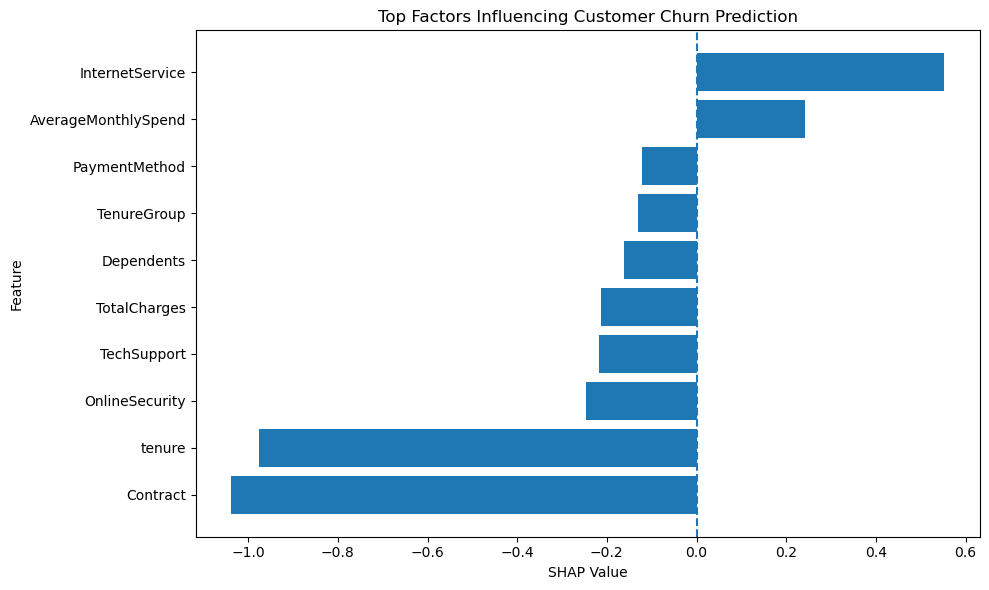

In [221]:
import matplotlib.pyplot as plt

top_features = (
    explanation
    .head(10)
    .sort_values(
        "SHAP_Value"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Factors Influencing Customer Churn Prediction"
)

plt.tight_layout()

plt.show()

In [222]:
import importlib
import src.predictor as predictor

importlib.reload(predictor)

print("Predictor updated successfully!")

Predictor updated successfully!


In [223]:
global_importance = (
    predictor.get_feature_importance()
)

global_importance.head(15)

,Feature,Importance
0,Contract,18.867007
1,tenure,11.314880
2,TotalCharges,8.208953
3,InternetService,7.675244
4,PaymentMethod,6.742892
5,AverageMonthlySpend,5.273979
6,TenureGroup,5.142803
7,OnlineSecurity,5.047906
8,MultipleLines,4.745096
9,MonthlyCharges,4.603576


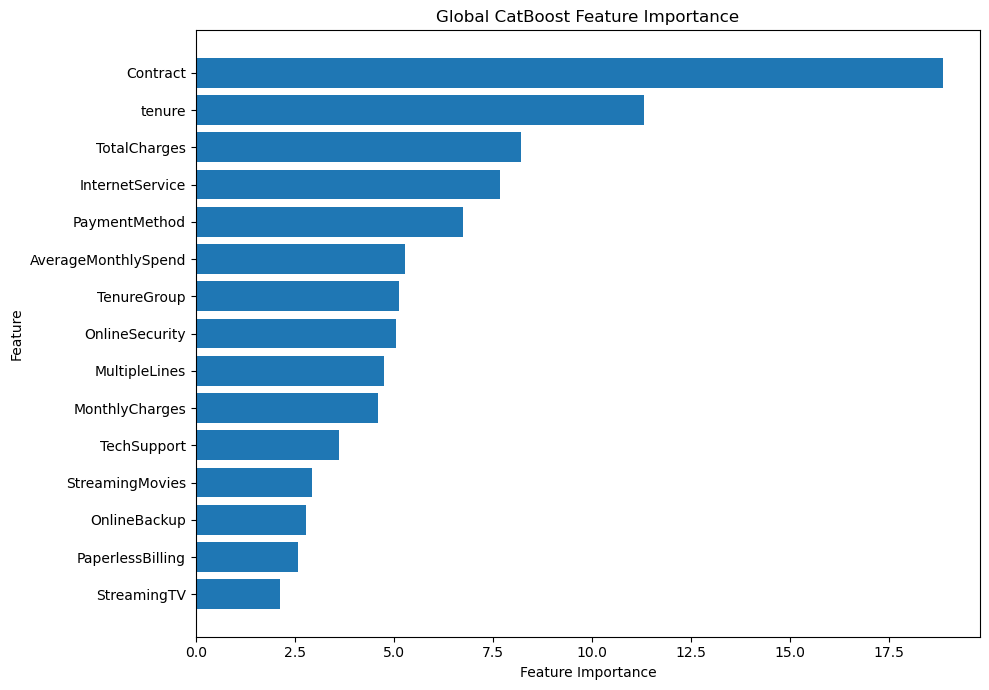

In [224]:
top_global_features = (
    global_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_global_features["Feature"],
    top_global_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global CatBoost Feature Importance"
)

plt.tight_layout()

plt.show()

In [225]:
import json
import os

catboost_row = final_model_comparison[
    final_model_comparison["Model"] == "CatBoost"
].iloc[0]

model_performance = {
    "model": "CatBoost",
    "accuracy": float(
        catboost_final_results["Accuracy"]
    ),
    "precision": float(
        catboost_final_results["Precision"]
    ),
    "recall": float(
        catboost_final_results["Recall"]
    ),
    "f1": float(
        catboost_final_results["F1"]
    ),
    "roc_auc": float(
        catboost_final_results["ROC_AUC"]
    ),
    "pr_auc": float(
        catboost_final_results["PR_AUC"]
    ),
    "threshold": float(
        catboost_best_threshold
    )
}

with open(
    "models/model_performance.json",
    "w"
) as file:

    json.dump(
        model_performance,
        file,
        indent=4
    )

print(
    "Model performance saved successfully!"
)

print(
    model_performance
)

Model performance saved successfully!
{'model': 'CatBoost', 'accuracy': 0.772888573456352, 'precision': 0.5533596837944664, 'recall': 0.7486631016042781, 'f1': 0.6363636363636364, 'roc_auc': 0.8453783357875431, 'pr_auc': 0.6621219788228028, 'threshold': 0.5399999999999998}


In [226]:
with open(
    "models/model_performance.json",
    "r"
) as file:

    performance_check = json.load(
        file
    )

performance_check

{'model': 'CatBoost',
 'accuracy': 0.772888573456352,
 'precision': 0.5533596837944664,
 'recall': 0.7486631016042781,
 'f1': 0.6363636363636364,
 'roc_auc': 0.8453783357875431,
 'pr_auc': 0.6621219788228028,
 'threshold': 0.5399999999999998}

In [227]:
import os

os.makedirs("data", exist_ok=True)

sample_batch = X_test_cb.head(25).copy()

sample_batch.to_csv(
    "data/sample_customers.csv",
    index=False
)

print("Sample batch CSV created successfully!")
print("Rows:", len(sample_batch))
print("Columns:", len(sample_batch.columns))

Sample batch CSV created successfully!
Rows: 25
Columns: 22


In [228]:
import importlib
import src.predictor as predictor

importlib.reload(predictor)

print("Validation function loaded successfully.")

Validation function loaded successfully.


In [229]:
import pandas as pd

test_df = pd.read_csv(
    "data/sample_customers.csv"
)

validation_result = (
    predictor.validate_input_dataframe(
        test_df
    )
)

print(
    validation_result["valid"]
)

print(
    validation_result["message"]
)

True
Input validation successful.


In [230]:
invalid_df = test_df.drop(
    columns=[
        test_df.columns[0]
    ]
)

validation_result = (
    predictor.validate_input_dataframe(
        invalid_df
    )
)

print(
    validation_result["valid"]
)

print(
    validation_result["message"]
)

False
Missing required columns: gender


In [231]:
import os

print("PROJECT FILES")
print("=" * 50)

for root, dirs, files in os.walk("."):
    level = root.replace(".", "").count(os.sep)
    
    if level > 2:
        continue

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

PROJECT FILES
./
    app.py
    app_backup.py
    Customer_Churn_Analysis.ipynb
    requirements.txt
    .ipynb_checkpoints/
        Customer_Churn_Analysis-checkpoint.ipynb
    catboost_info/
        catboost_training.json
        learn_error.tsv
        time_left.tsv
        learn/
            events.out.tfevents
        tmp/
    data/
        sample_customers.csv
        raw/
            WA_Fn-UseC_-Telco-Customer-Churn.csv
    models/
        catboost_churn_model.cbm
        catboost_threshold.joblib
        churn_threshold.joblib
        feature_metadata.json
        feature_schema.json
        model_metadata.json
        model_performance.json
        xgboost_churn_pipeline.joblib
    notebooks/
    reports/
        catboost_threshold_analysis.csv
        final_customer_risk_predictions.csv
        final_model_comparison.csv
        model_comparison.csv
        sample_predictions.csv
        figures/
    src/
        predictor.py
        predictor_backup.py
        __pycache__/
 

In [232]:
import os

model_dir = "models"

print("MODEL FILES")
print("=" * 50)

if os.path.exists(model_dir):

    for file in os.listdir(model_dir):
        path = os.path.join(
            model_dir,
            file
        )

        size_mb = (
            os.path.getsize(path)
            / (1024 * 1024)
        )

        print(
            f"{file:<40} "
            f"{size_mb:.2f} MB"
        )

else:

    print(
        "ERROR: models folder not found."
    )

MODEL FILES
catboost_churn_model.cbm                 0.65 MB
catboost_threshold.joblib                0.00 MB
churn_threshold.joblib                   0.00 MB
feature_metadata.json                    0.00 MB
feature_schema.json                      0.00 MB
model_metadata.json                      0.00 MB
model_performance.json                   0.00 MB
xgboost_churn_pipeline.joblib            0.74 MB
